# Exploring the Link Between Personality Traits and Substance Use

Dataset: https://www.kaggle.com/datasets/mexwell/drug-consumption-classification/data

First, lets import necessary modules and create some utility for the notebook

In [1]:
import sys
import pandas as pd
import plotnine as pn
import sklearn as sk
import numpy as np
import data_analysis # Custom module, which contains functions to analyze the data
import data_reading # Custom module, which contains functions pertaining to reading the data
import matplotlib.pyplot as plt
from scipy import stats
from IPython.core.magic import register_cell_magic
from IPython import get_ipython

@register_cell_magic
def skip_if(line, cell):
    if eval(line):
        return
    get_ipython().run_cell(cell)

## Data reading & cleaning

First, lets read in the data, and create a human-readable format of it.

In [2]:
data = data_reading.read_data("data/drug_consumption.csv")
dataOG = data.copy() # In case we need to work on the completely original raw data later
human_readable_data = data_reading.convert_data(data)
human_readable_data = data_reading.convert_drug_usage_classifiers(human_readable_data)
human_readable_data["Education"] = pd.Categorical(
        human_readable_data["Education"],
        categories=list(data_reading.EDUCATION.values()),
        ordered=True,
    )
human_readable_data

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,35-44,Female,Professional Certificate/Diploma,UK,Mixed-White/Asian,39.0,36.0,42.0,37.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
1,2,25-34,Male,Doctorate Degree,UK,White,29.0,52.0,55.0,48.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Year,Never Used,Used in Last Month,Never Used,Never Used
2,3,35-44,Male,Professional Certificate/Diploma,UK,White,31.0,45.0,40.0,32.0,...,Never Used,Never Used,Never Used,Never Used,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Never Used
3,4,18-24,Female,Master's Degree,UK,White,34.0,34.0,46.0,47.0,...,Never Used,Never Used,Used in Last Decade,Never Used,Never Used,Never Used,Never Used,Used in Last Decade,Never Used,Never Used
4,5,35-44,Female,Doctorate Degree,UK,White,43.0,28.0,43.0,41.0,...,Used over a Decade Ago,Never Used,Never Used,Used over a Decade Ago,Never Used,Never Used,Used in Last Decade,Used in Last Decade,Never Used,Never Used
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,18-24,Female,"Some College, No Certificate/Degree",USA,White,25.0,51.0,57.0,48.0,...,Never Used,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Never Used,Never Used,Never Used,Used in Last Week
1881,1885,18-24,Male,"Some College, No Certificate/Degree",USA,White,33.0,51.0,50.0,48.0,...,Used in Last Decade,Never Used,Never Used,Used in Last Year,Used in Last Week,Used in Last Month,Used in Last Month,Used in Last Week,Never Used,Never Used
1882,1886,25-34,Female,University Degree,USA,White,47.0,30.0,37.0,31.0,...,Used in Last Month,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Never Used,Used in Last Decade,Used in Last Day,Never Used,Never Used
1883,1887,18-24,Female,"Some College, No Certificate/Degree",USA,White,45.0,26.0,48.0,32.0,...,Used in Last Year,Never Used,Never Used,Used in Last Year,Used in Last Year,Never Used,Used in Last Year,Used in Last Month,Never Used,Never Used


### Start with initial visualizations and filtering the data

Let's create the initial DataFrame and visualization to see how many users of each drug in each category there are.

In [3]:
# Bring data to a shape possible to be shown as a plot
drug_usage = data_analysis.get_columns_unique_value_counts(data[data_reading.DRUG_TYPES].copy())
drug_usage = drug_usage.transpose().reset_index(names="Drug")
drug_usage = drug_usage.melt(id_vars="Drug", var_name="Usage", value_name="Amount")

# Replace NaN amounts with 0-s
drug_usage = drug_usage.fillna(0)

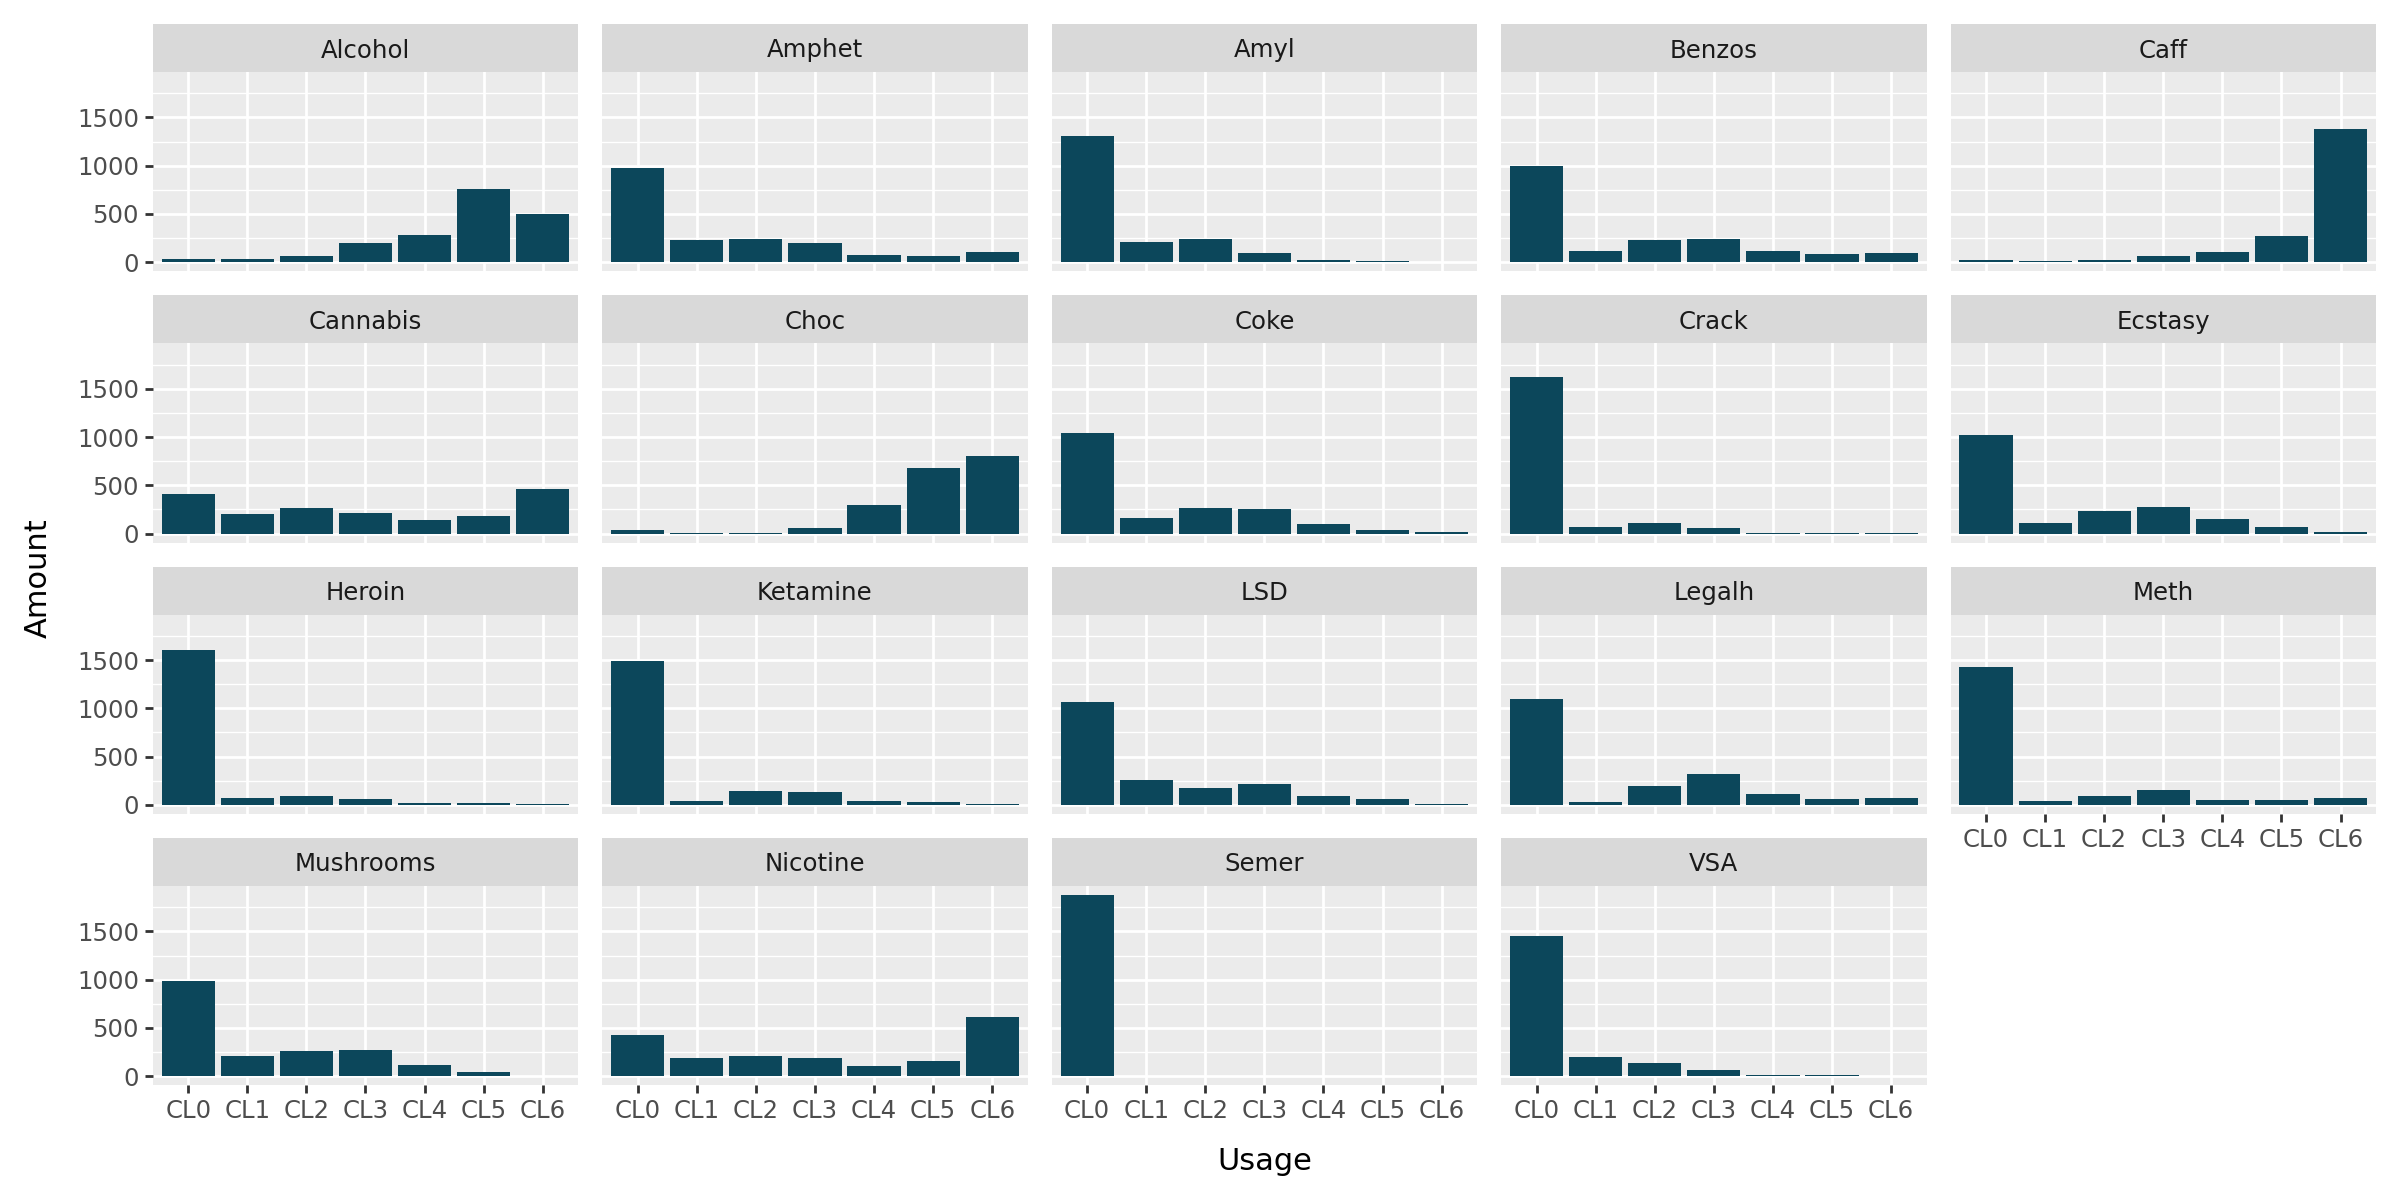

In [4]:
(
    pn.ggplot(drug_usage, pn.aes("Usage", "Amount", fill="Drug")) 
    + pn.geom_col(fill="#0C475B") 
    + pn.facet_wrap("Drug")
    + pn.theme(figure_size=(12, 6))
)

Here we can already see a few oddities. Namely **Semer** having weird usage rates. When reading from Kaggle we see, that we should exclude all who claimed to use Semer, as it was there just to filter out over-claimers.

Lets also see how many users each drug has.

In [5]:
drug_users = drug_usage[drug_usage["Usage"] != "CL0"]
drug_users = drug_users.groupby(["Drug"], as_index=False)["Amount"].sum()
drug_users["Amount"] = drug_users["Amount"].astype(int)

# Sort values
drug_users = drug_users.assign(
    Drug=pd.Categorical(drug_users["Drug"], categories=drug_users.sort_values("Amount", ascending=False)["Drug"])
)

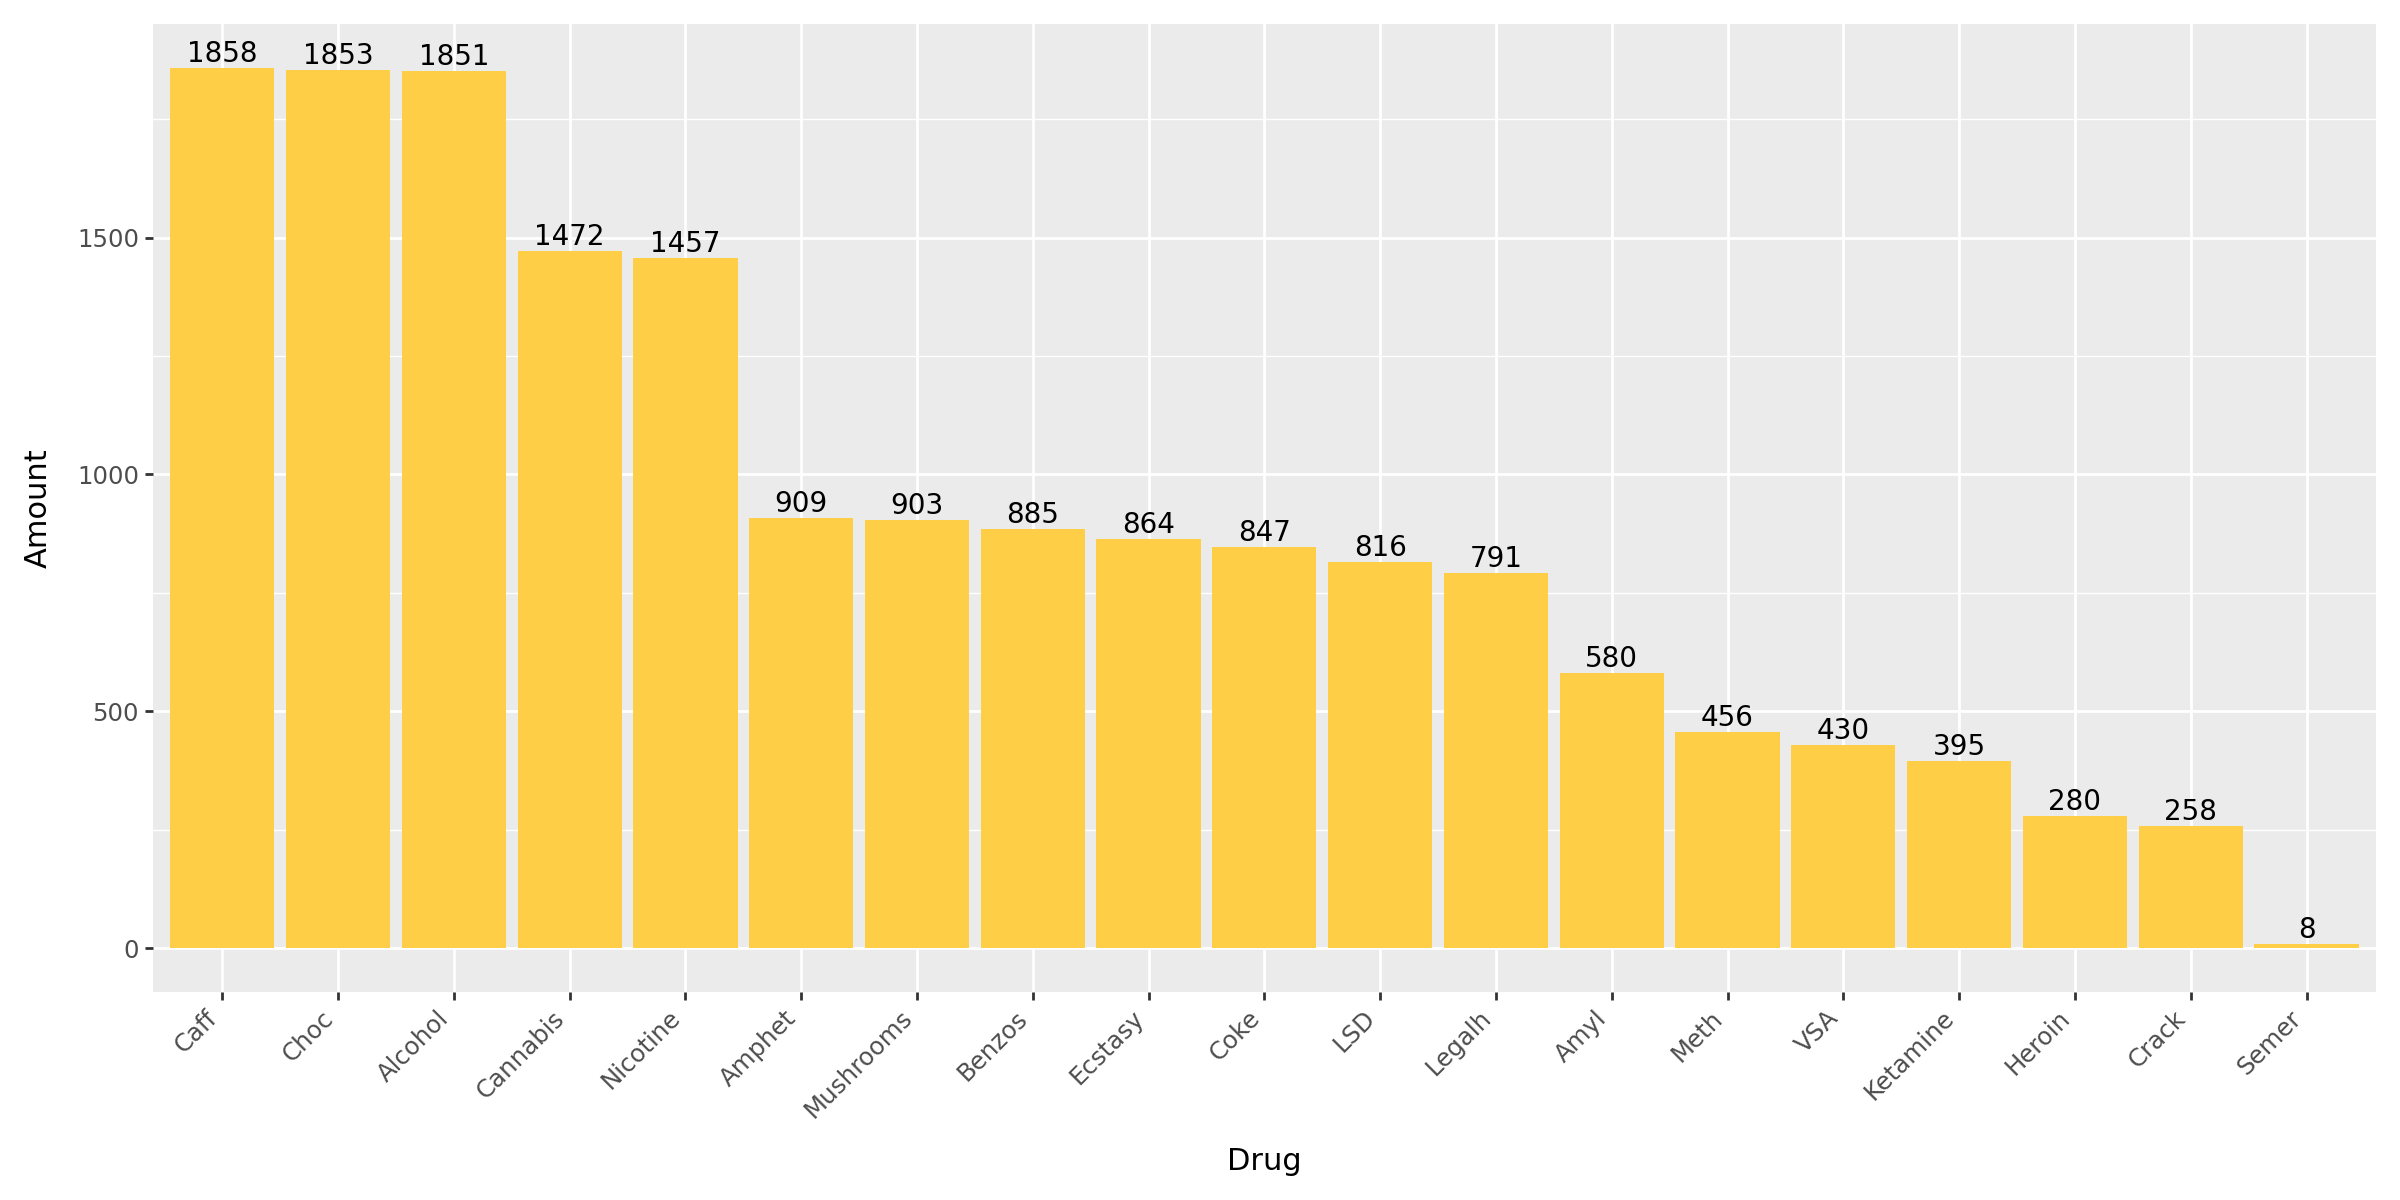

In [6]:
(
    pn.ggplot(drug_users, pn.aes("Drug", "Amount"))
    + pn.geom_col(fill="#ffce47")
    + pn.geom_text(pn.aes(label = "Amount"), size=10, va="bottom")
    + pn.labs(y="Amount")
    + pn.theme(figure_size=(12, 6), axis_text_x=pn.element_text(rotation=45, hjust=1))
)

We again notice extremely low usage on **Semer (Semeron)**, the fake drug. Lets filter them out and also remove it from our constants.

In [7]:
%%skip_if "Semer" not in data_reading.DRUG_TYPES # Skip running this cell if semer is not present anymore
human_readable_data = human_readable_data[human_readable_data["Semer"] == "Never Used"]
data = data[data["Semer"] == "CL0"]
human_readable_data = human_readable_data.drop("Semer", axis=1)
data = data.drop("Semer", axis=1)
data_reading.DRUG_TYPES.remove("Semer")

Lets now visualize the distribution of various demographics, starting from ethnicity.

In [8]:
ethnicities = human_readable_data["Ethnicity"].reset_index()
ethnicities = ethnicities.groupby("Ethnicity").size().reset_index(name="Amount")
ethnicities

,Ethnicity,Amount
0,Asian,25
1,Black,33
2,Mixed-Black/Asian,3
3,Mixed-White/Asian,20
4,Mixed-White/Black,19
5,Other,62
6,White,1715


Here we notice, that all races, other than white, are barely represented. Lets filter them out to avoid ethnicity-induced differences.

In [9]:
human_readable_data = human_readable_data[human_readable_data["Ethnicity"] == "White"]
data = data[data["Ethnicity"] == -0.31685]

Next, lets see how equal the distribution of countries is.

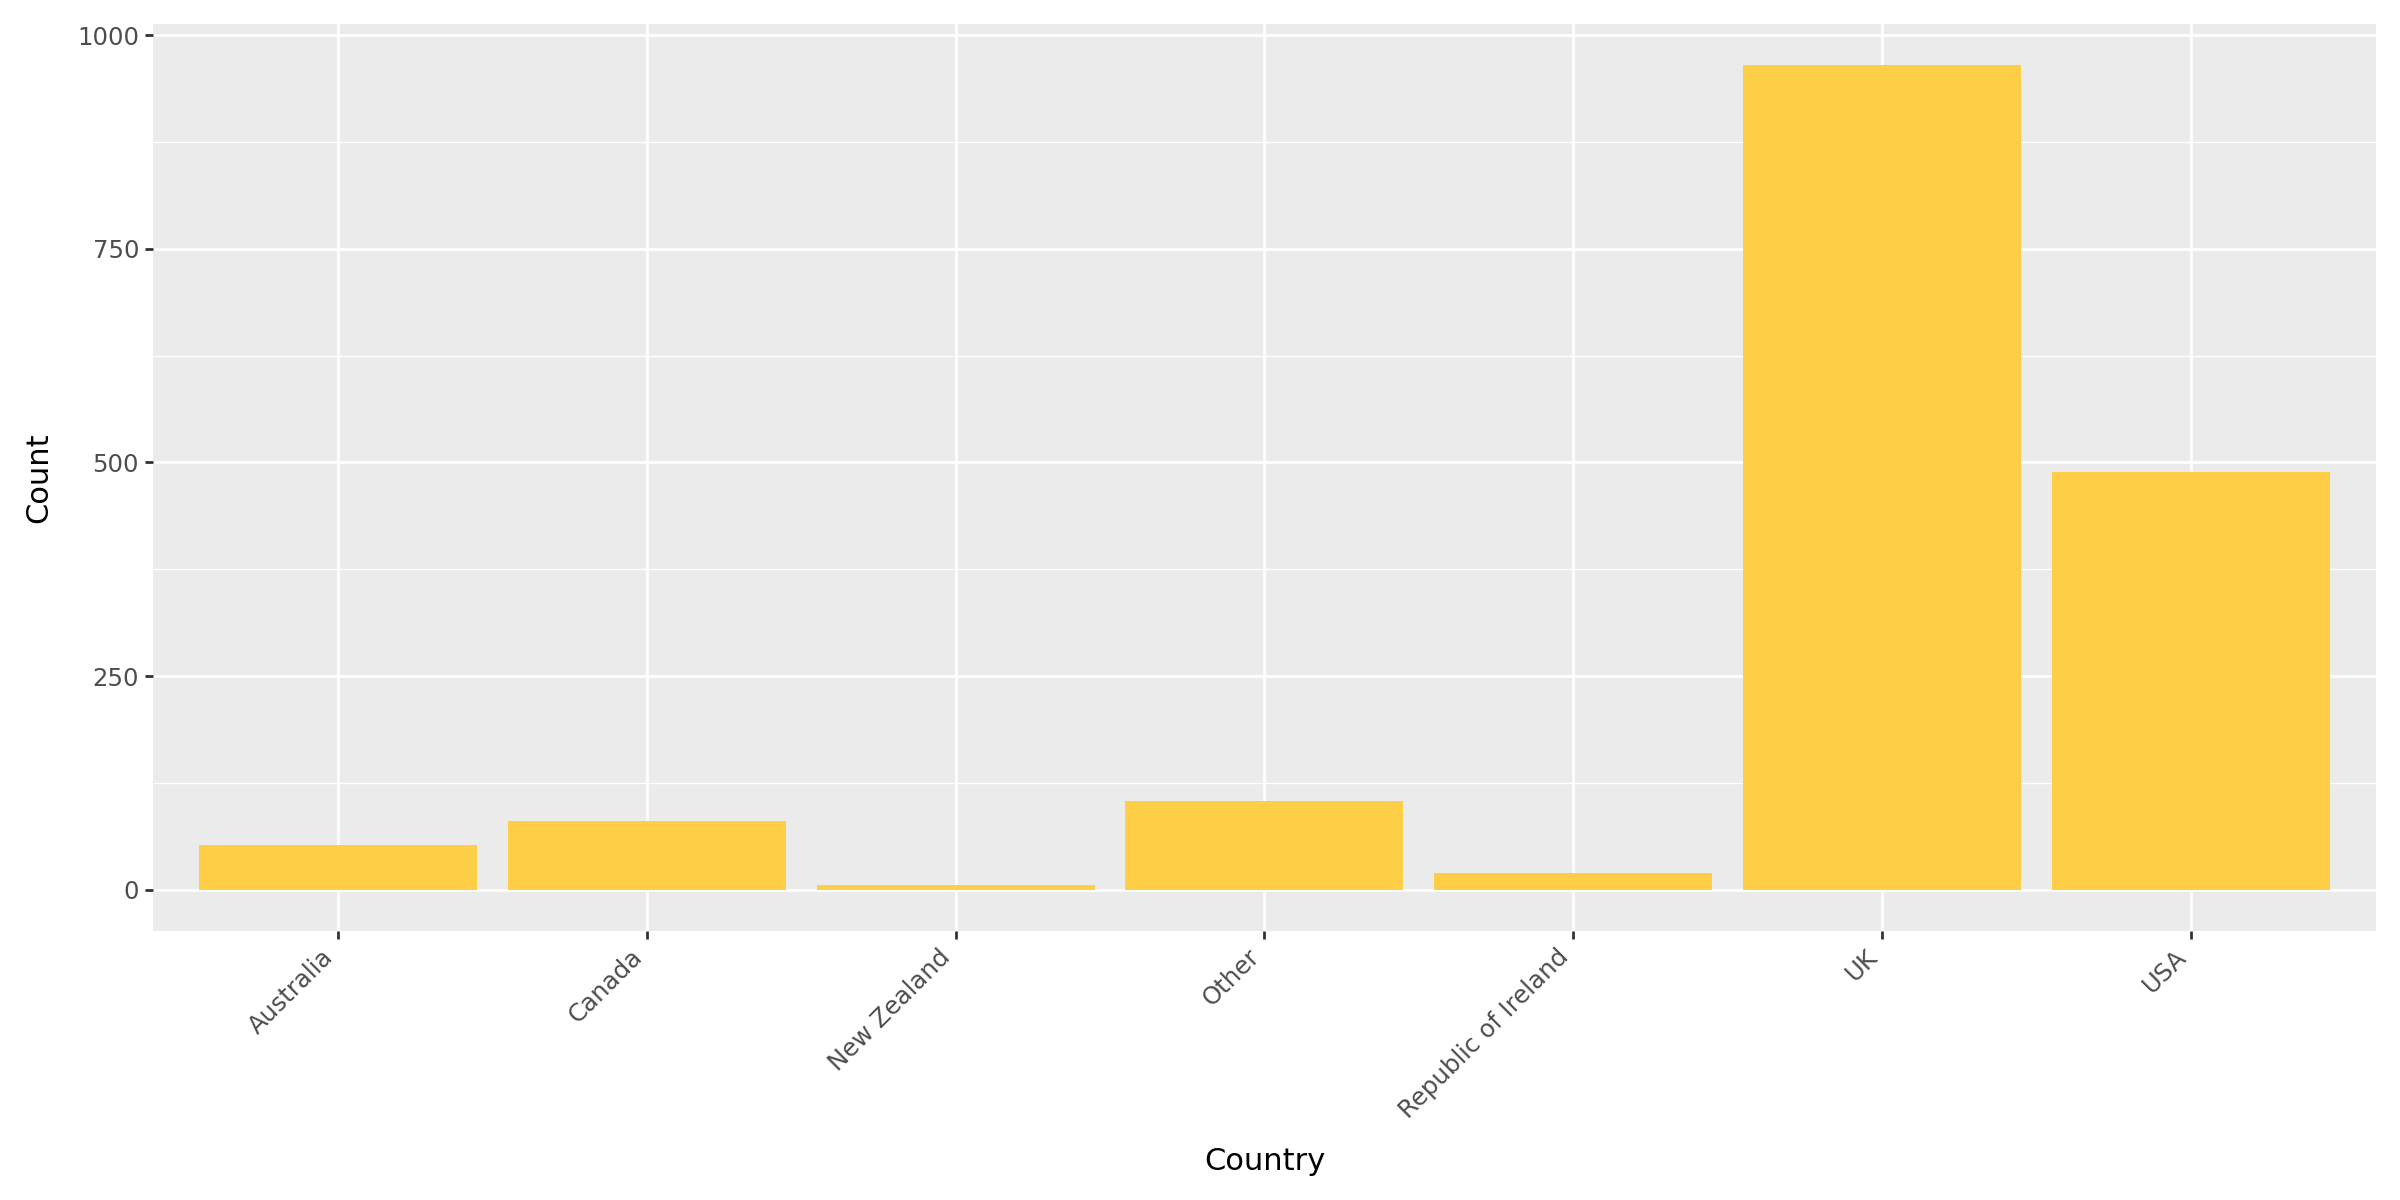

In [10]:
countries = human_readable_data.groupby("Country")["Country"].size().rename("Count").reset_index()
(
    pn.ggplot(countries, pn.aes("Country", "Count"))
    + pn.geom_col(fill="#ffce47")
    + pn.theme(figure_size=(12, 6), axis_text_x=pn.element_text(rotation=45, hjust=1))
)

Lets filter out data from countries other than UK and USA, due to lack of data (too few samples). It is to reduce the amount of change due to cultural and regional differences.

In [11]:
human_readable_data = human_readable_data[human_readable_data["Country"].isin(["USA", "UK"])]
data = data[data["Country"].isin([0.96082, -0.57009])] # Numeric values for USA and UK


Lets also see the distribution of age groups.

In [12]:
ages = human_readable_data["Age"].reset_index()
ages = ages.groupby("Age").size().reset_index(name="Amount")
ages

,Age,Amount
0,18-24,463
1,25-34,368
2,35-44,284
3,45-54,246
4,55-64,79
5,65+,14


Filter out everyone who is 65+ due to lack of datapoints.

In [13]:
human_readable_data = human_readable_data[human_readable_data["Age"] != "65+"]
data = data[data["Age"] != 2.59171] # Numeric value for 65+ age category

Lets also see how the distribution of education levels are.

In [14]:
edu_levels = human_readable_data["Education"].reset_index().groupby("Education", observed=True).size().reset_index(name="Amount")
edu_levels

,Education,Amount
0,Left School Before 16 years,21
1,Left School at 16 years,79
2,Left School at 17 years,19
3,Left School at 18 years,61
4,"Some College, No Certificate/Degree",381
5,Professional Certificate/Diploma,198
6,University Degree,386
7,Master's Degree,224
8,Doctorate Degree,71


Filter out everyone who left the school **before 16** and **at 17 years** due to lack of datapoints.

In [15]:
%%skip_if -1.43719 not in data_reading.EDUCATION.keys() # Skip running this cell if semer is not present anymore

human_readable_data = human_readable_data[~human_readable_data["Education"].isin(["Left School Before 16 years", "Left School at 17 years"])]
data = data[~data["Education"].isin([-2.43591, -1.43719])] # Numeric values for left school before 16 and at 17 values
del data_reading.EDUCATION[-2.43591]
del data_reading.EDUCATION[-1.43719]

## Drug Usage Visualization

### General usage statistics

Now where we have cleaned up the data, lets create a new visualization of drug usage, to get an initial understanding of the data.

In [16]:
# Make new plots again, with reliable data
# Bring data to a shape possible to be shown as a plot
drug_usage = data_analysis.get_columns_unique_value_counts(human_readable_data[data_reading.DRUG_TYPES])
drug_usage = drug_usage.transpose().reset_index(names="Drug")
drug_usage = drug_usage.melt(id_vars="Drug", var_name="Usage", value_name="Amount")

# Replace NaN amounts with 0-s
drug_usage = drug_usage.fillna(0)

In [17]:
#Adding one row for crack with used in last day to not be 0 (does not make data less acurate, but makes it a lot more visually appealing
drug_usage_forPlot = drug_usage.copy()
new_row = {
    "Drug": "Crack",
    "Usage": "Used in Last Day",
    "Amount": 1.0,   # change this number if needed
}

drug_usage_forPlot = pd.concat([drug_usage_forPlot, pd.DataFrame([new_row])], ignore_index=True)

Here we make the data relativistic, to more accurately show the amount of users for each drug.

In [18]:
df = drug_usage.copy()

# total per drug
df["Total"] = df.groupby("Drug")["Amount"].transform("sum")

# convert to percent
df["Percent"] = df["Amount"] / df["Total"] * 100

#df = drug_usage[drug_usage["Amount"] > 0].copy()
df = df[df["Percent"] >= 1].copy()

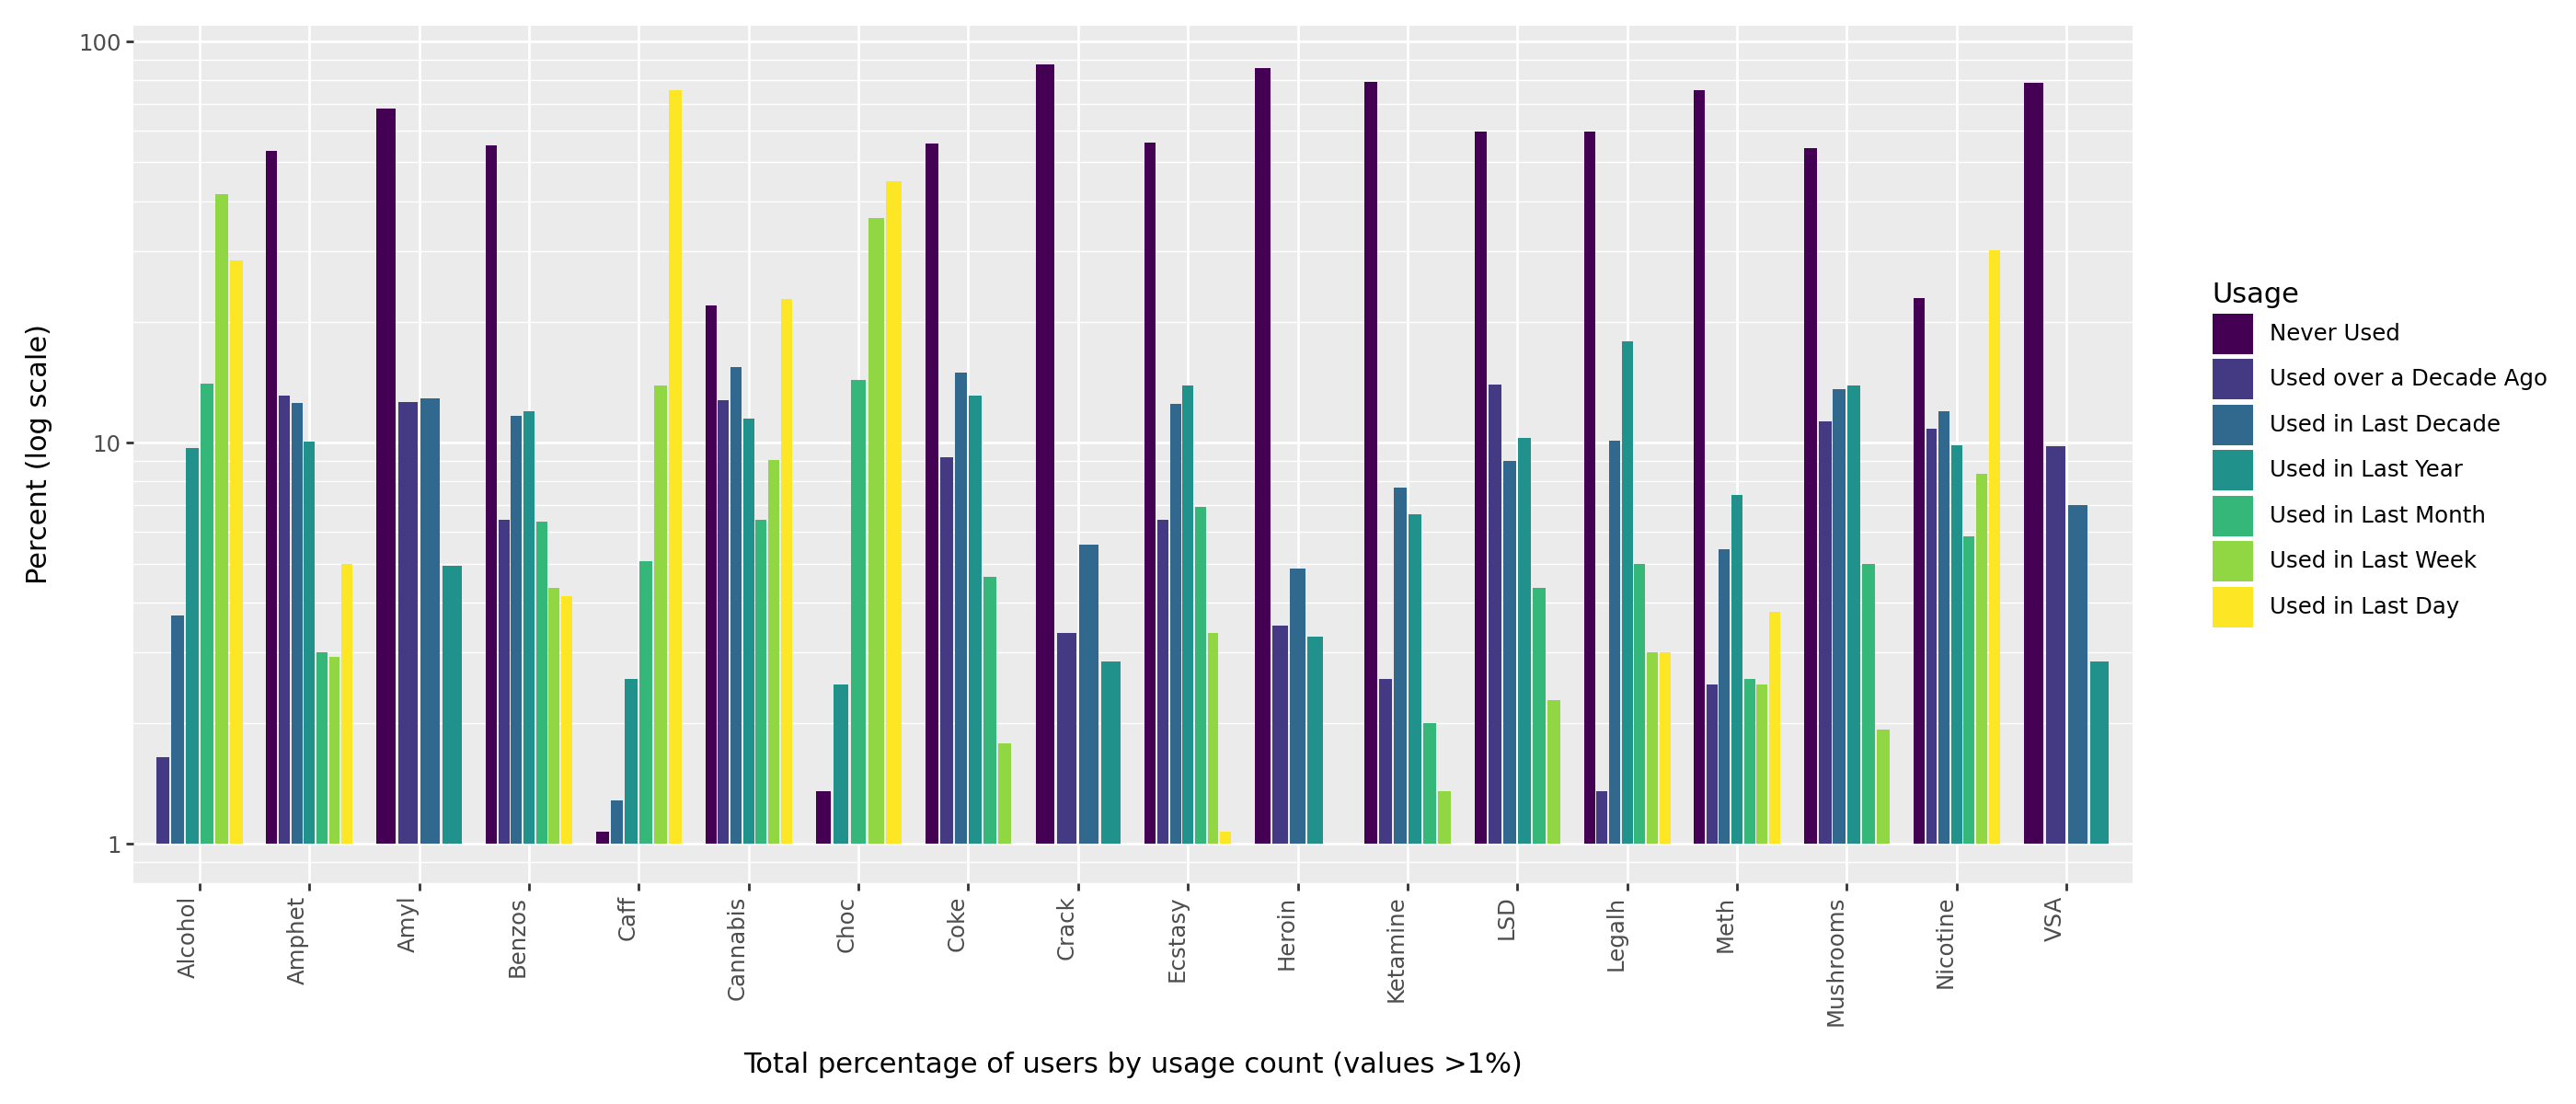

In [19]:
df["Usage"] = pd.Categorical(df["Usage"], categories=data_reading.DRUG_CLASSIFIER.values(), ordered=True)
(
    pn.ggplot(df, pn.aes("Drug", "Percent", fill="Usage"))
    + pn.geom_col(position=pn.position_dodge(width=0.8), width=0.7)
    + pn.scale_y_log10()
    + pn.labs(
        x="Total percentage of users by usage count (values >1%)",
        y="Percent (log scale)"
    )
    + pn.theme(
        figure_size=(14, 6),
        axis_text_x=pn.element_text(rotation=90, ha="right"),
    )
)


As expected, most people in this study haven't used most of the drugs. Also, as expected we have high amounts of **Alcohol, Caffeine and Chocolate users**. This study also seems to have large numbers of **active and ex-users of cannabis and nicotine**. While nicotine usage is nothing out of the ordinary, this large amount of active and ex-users of cannabis is surprising, considering it is illegal to be used for recreational use. But also taking into account that cannabis is one of the most popular drugs, it is nothing out of the ordinary.

We can quickly visualize and see proportionally, how many users of cannabis are in both UK and US.

In [20]:
users_amount_by_country = data_analysis.get_uk_and_us_cannabis_users(human_readable_data[["Country", "Cannabis"]])

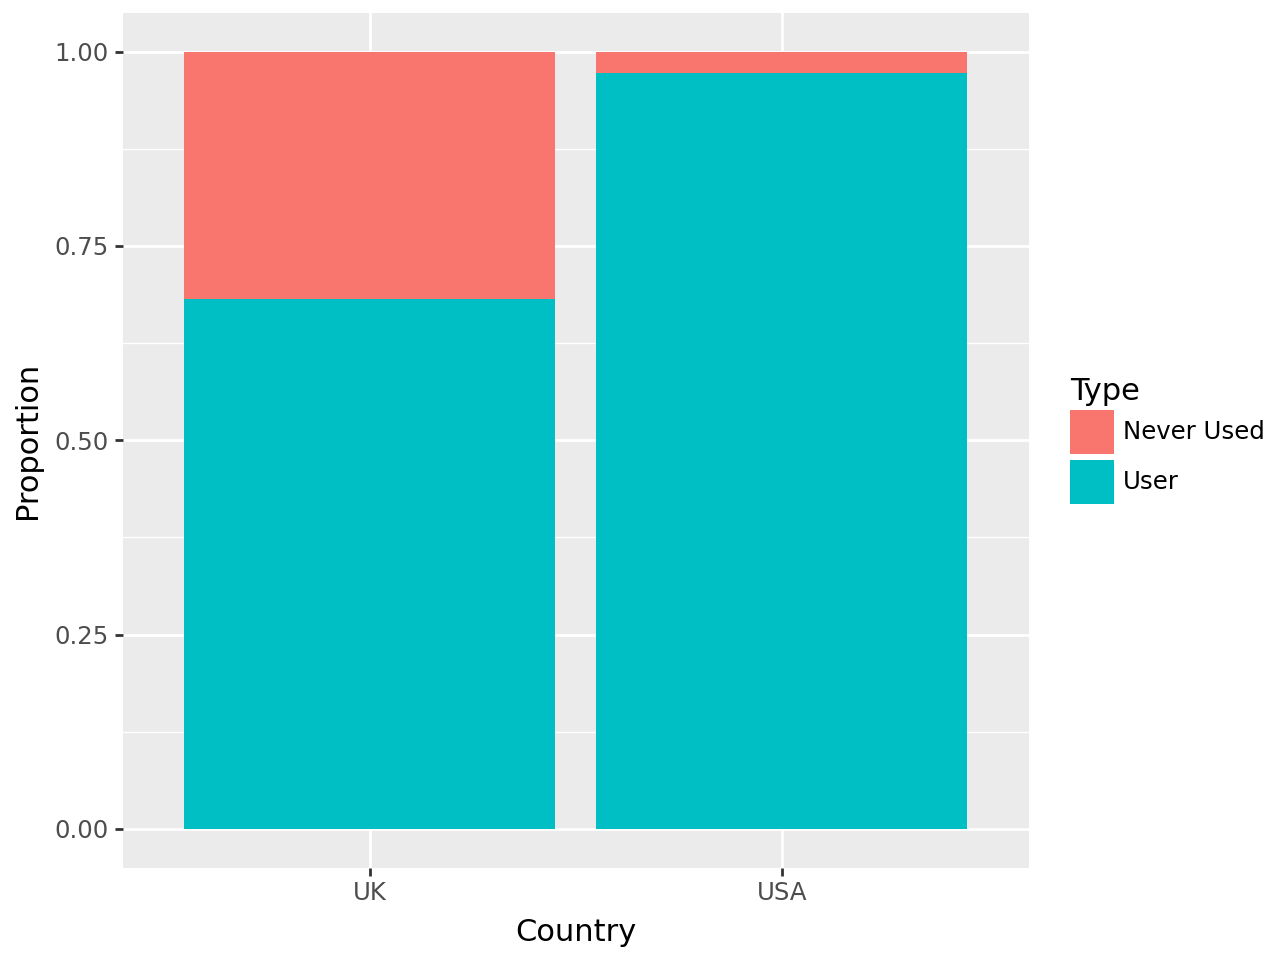

In [21]:
(
    pn.ggplot(users_amount_by_country, pn.aes("Country", "Proportion", fill="Type"))
    + pn.geom_col()
)

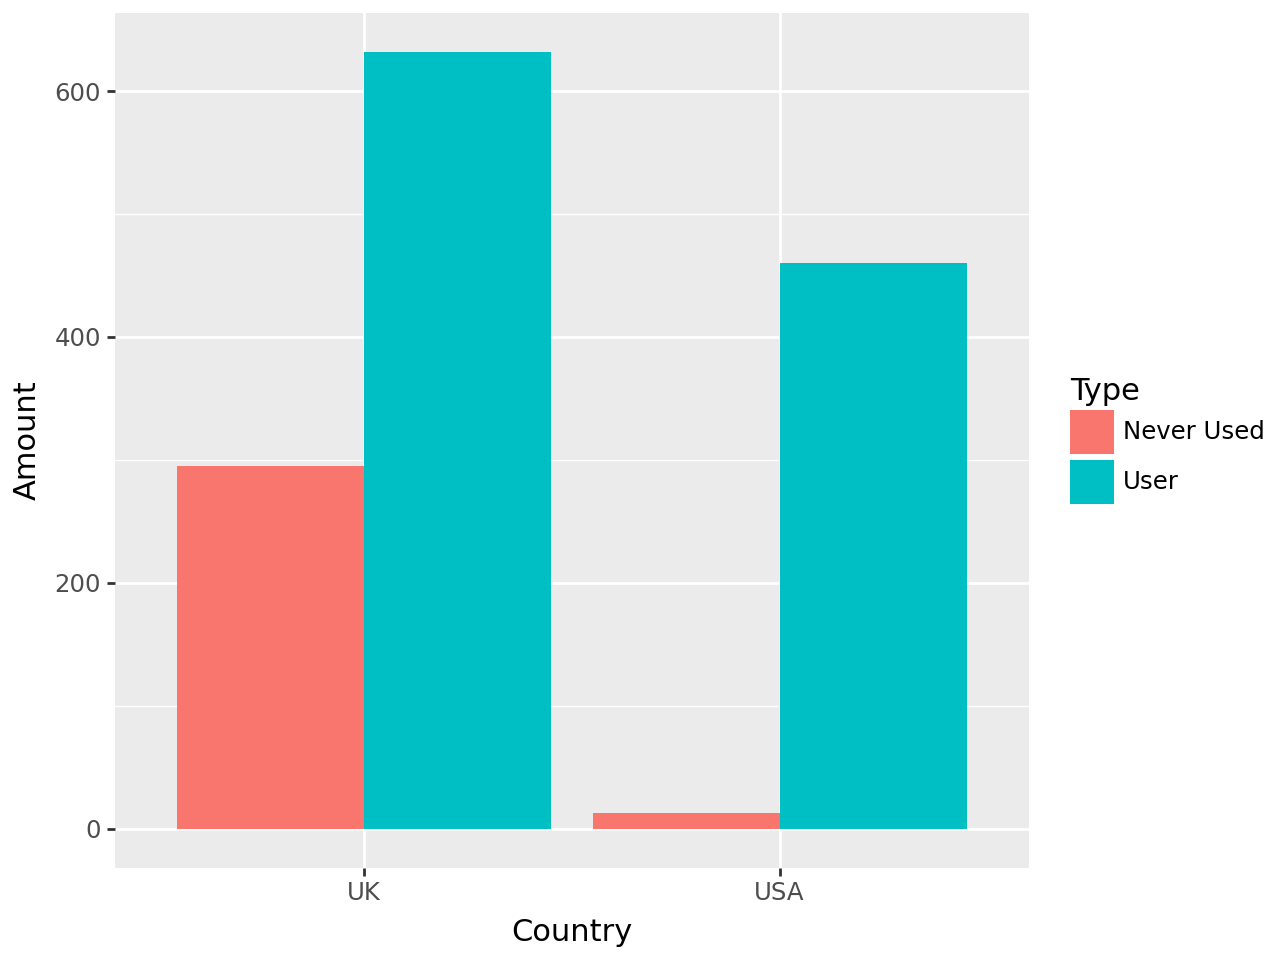

In [22]:
(
    pn.ggplot(users_amount_by_country, pn.aes("Country", "Amount", fill="Type"))
    + pn.geom_col(position="dodge")
)

We can see that, even though the US has more cannabis users and ex-users proportionally, UK still has majority of the users in this dataset. Thus, even though it is skewed by USA, it is not significant enough to attribute it to only USA.

But if we've already visualized the proportion of cannabis users, we might as well look what other drugs have in store for us, compared to usage between USA and UK. 

In [23]:
data2 = data.copy()

data2 = data_reading.convert_drug_usage_classifiers(data2)  # map CL0..CL6 → 'Never Used', etc.
data2 = data_reading.convert_data(data2)

/home/rikkss/Documents/data-science-project/data_analysis.py:665: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


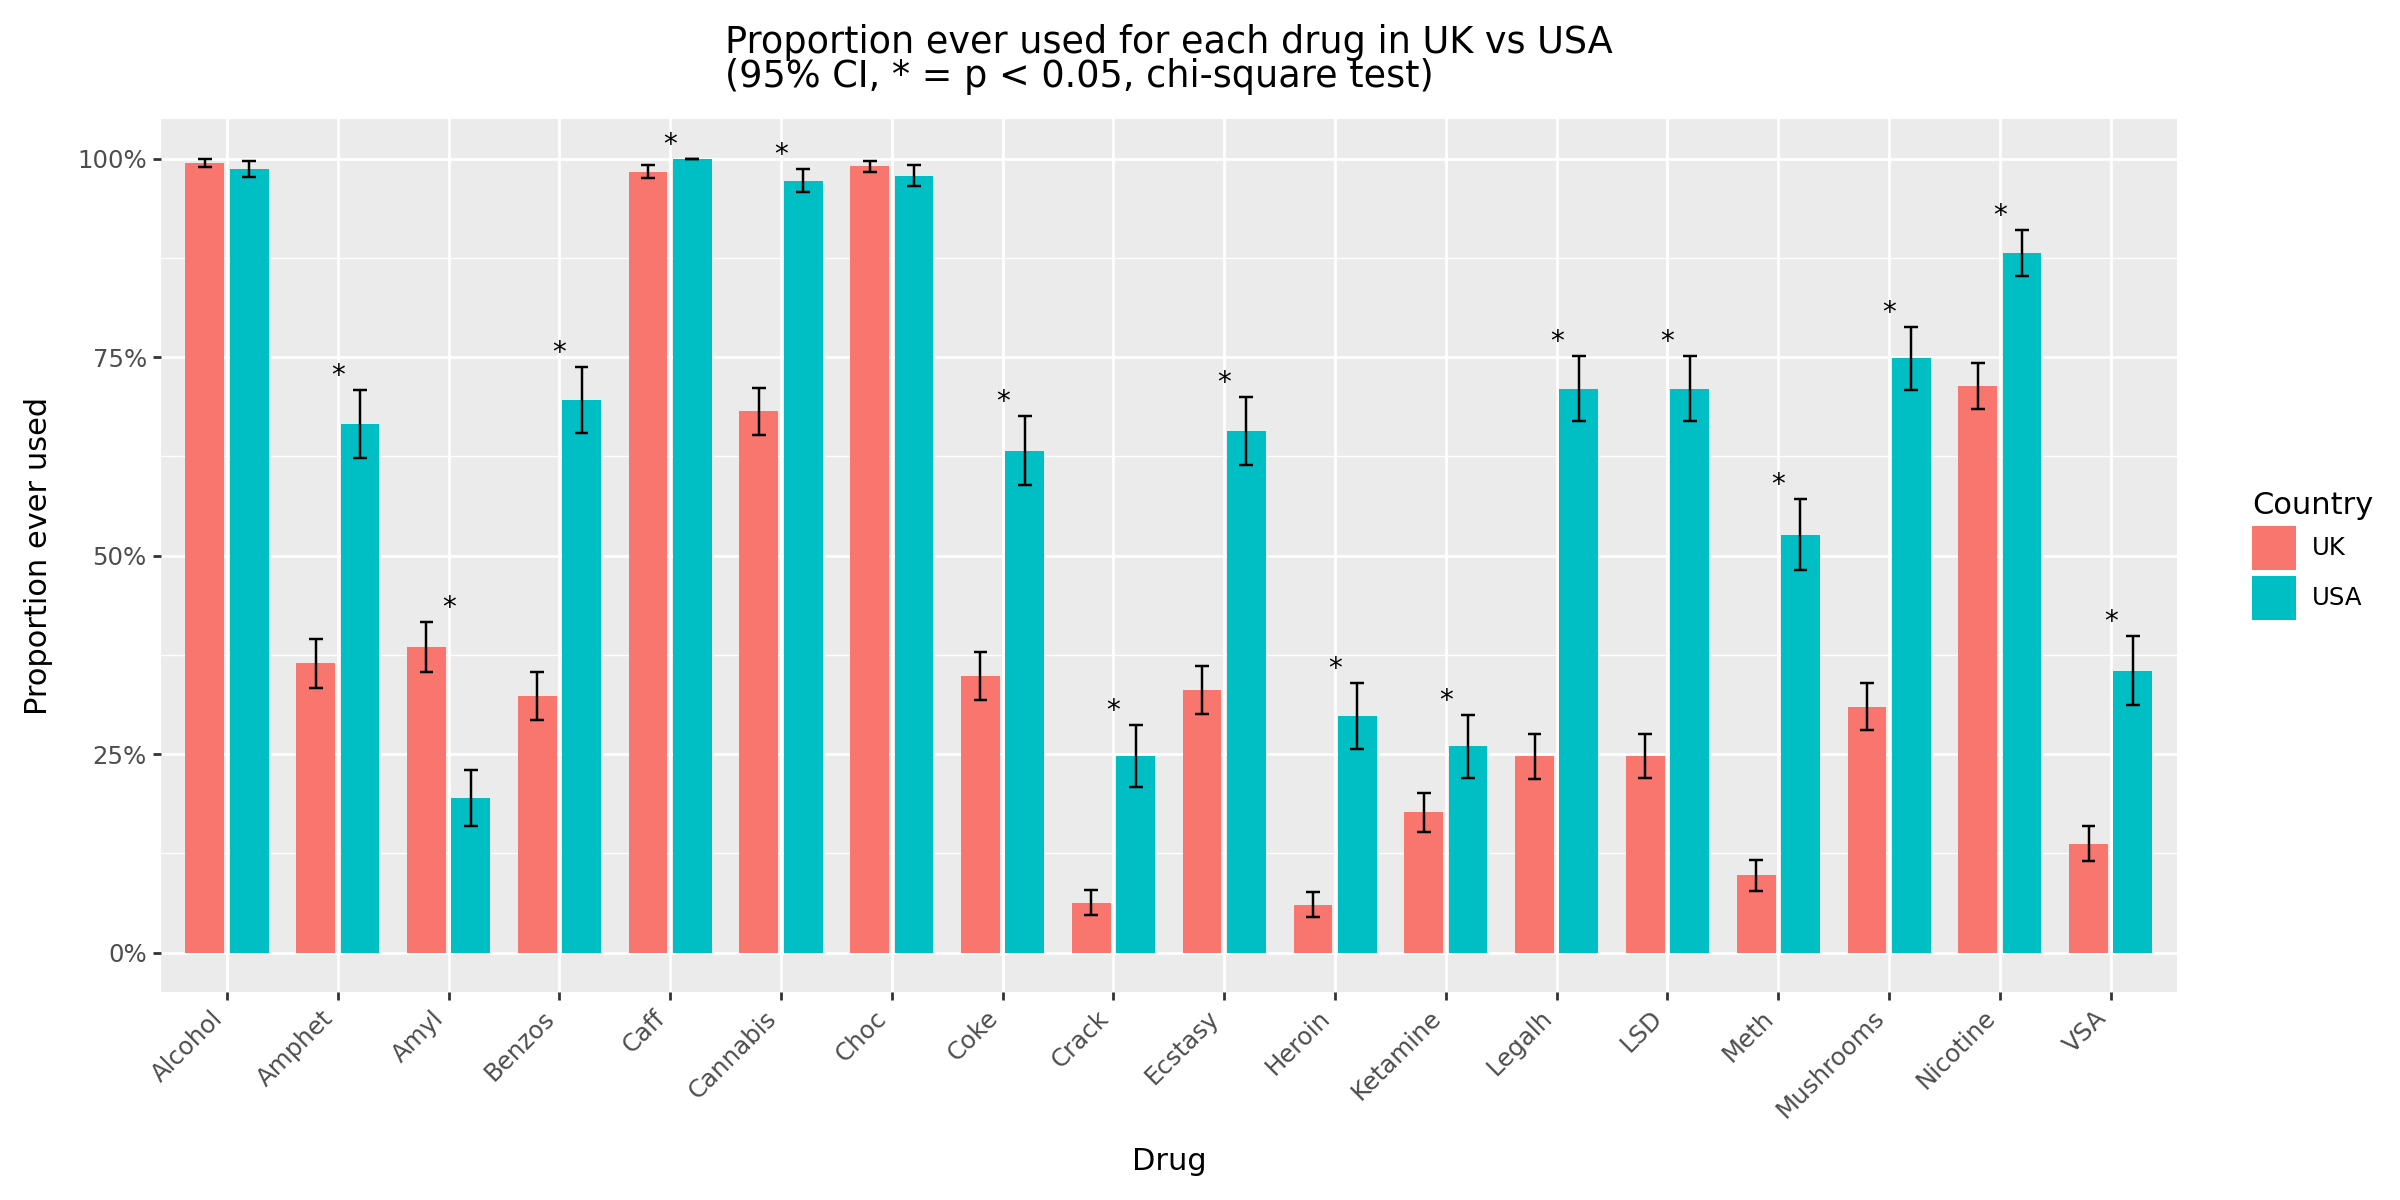

In [24]:
data_analysis.plot_all_drug_usage_country(data2)

Here we can see, that people in the USA use more drugs than people in the UK based on this dataset.

Lets also compare if there is any significant difference between the countries personality traits to take into account for.

/home/rikkss/Documents/data-science-project/data_analysis.py:730: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


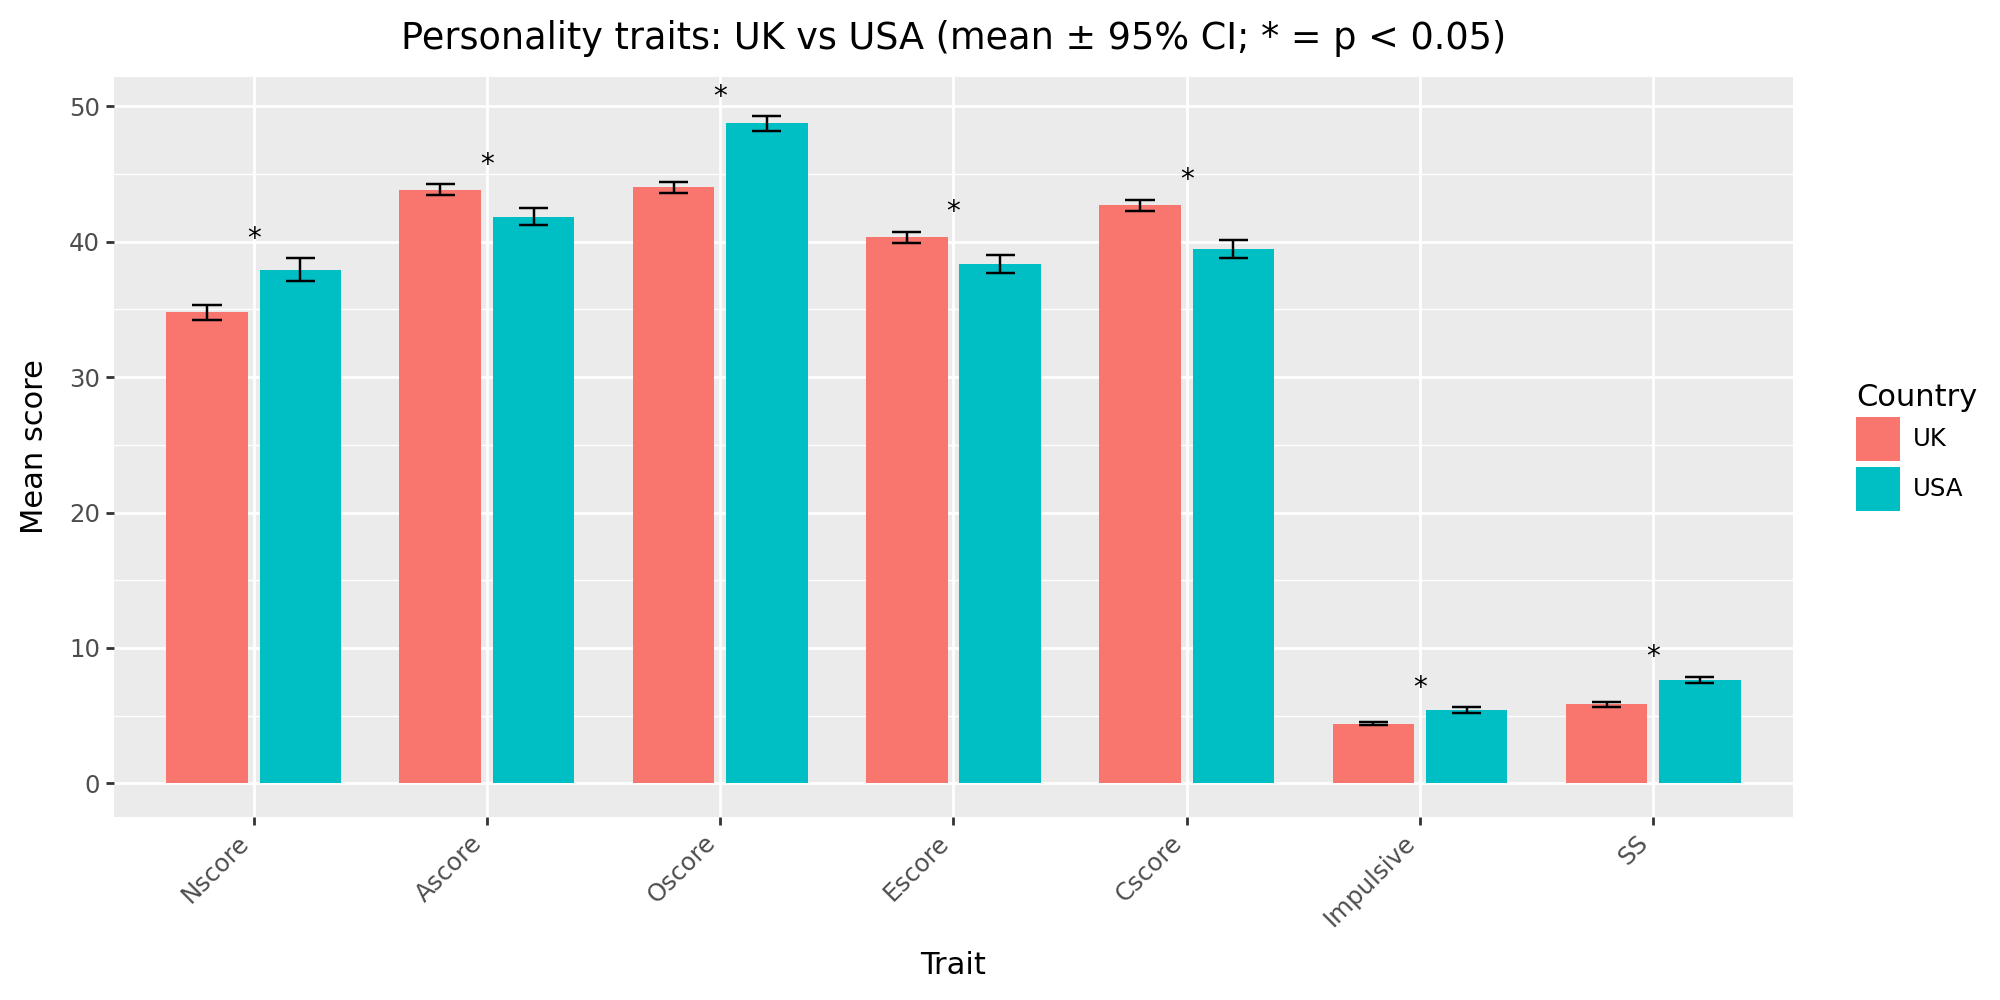

In [25]:
data_analysis.plot_all_traits_country(data2)

The differences don't seem to be significant enough to take into account.

## Education & Drug Usage in USA and UK

Lets first see, if there are significant differences between education in the USA and the UK.

/home/rikkss/Documents/data-science-project/data_analysis.py:809: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


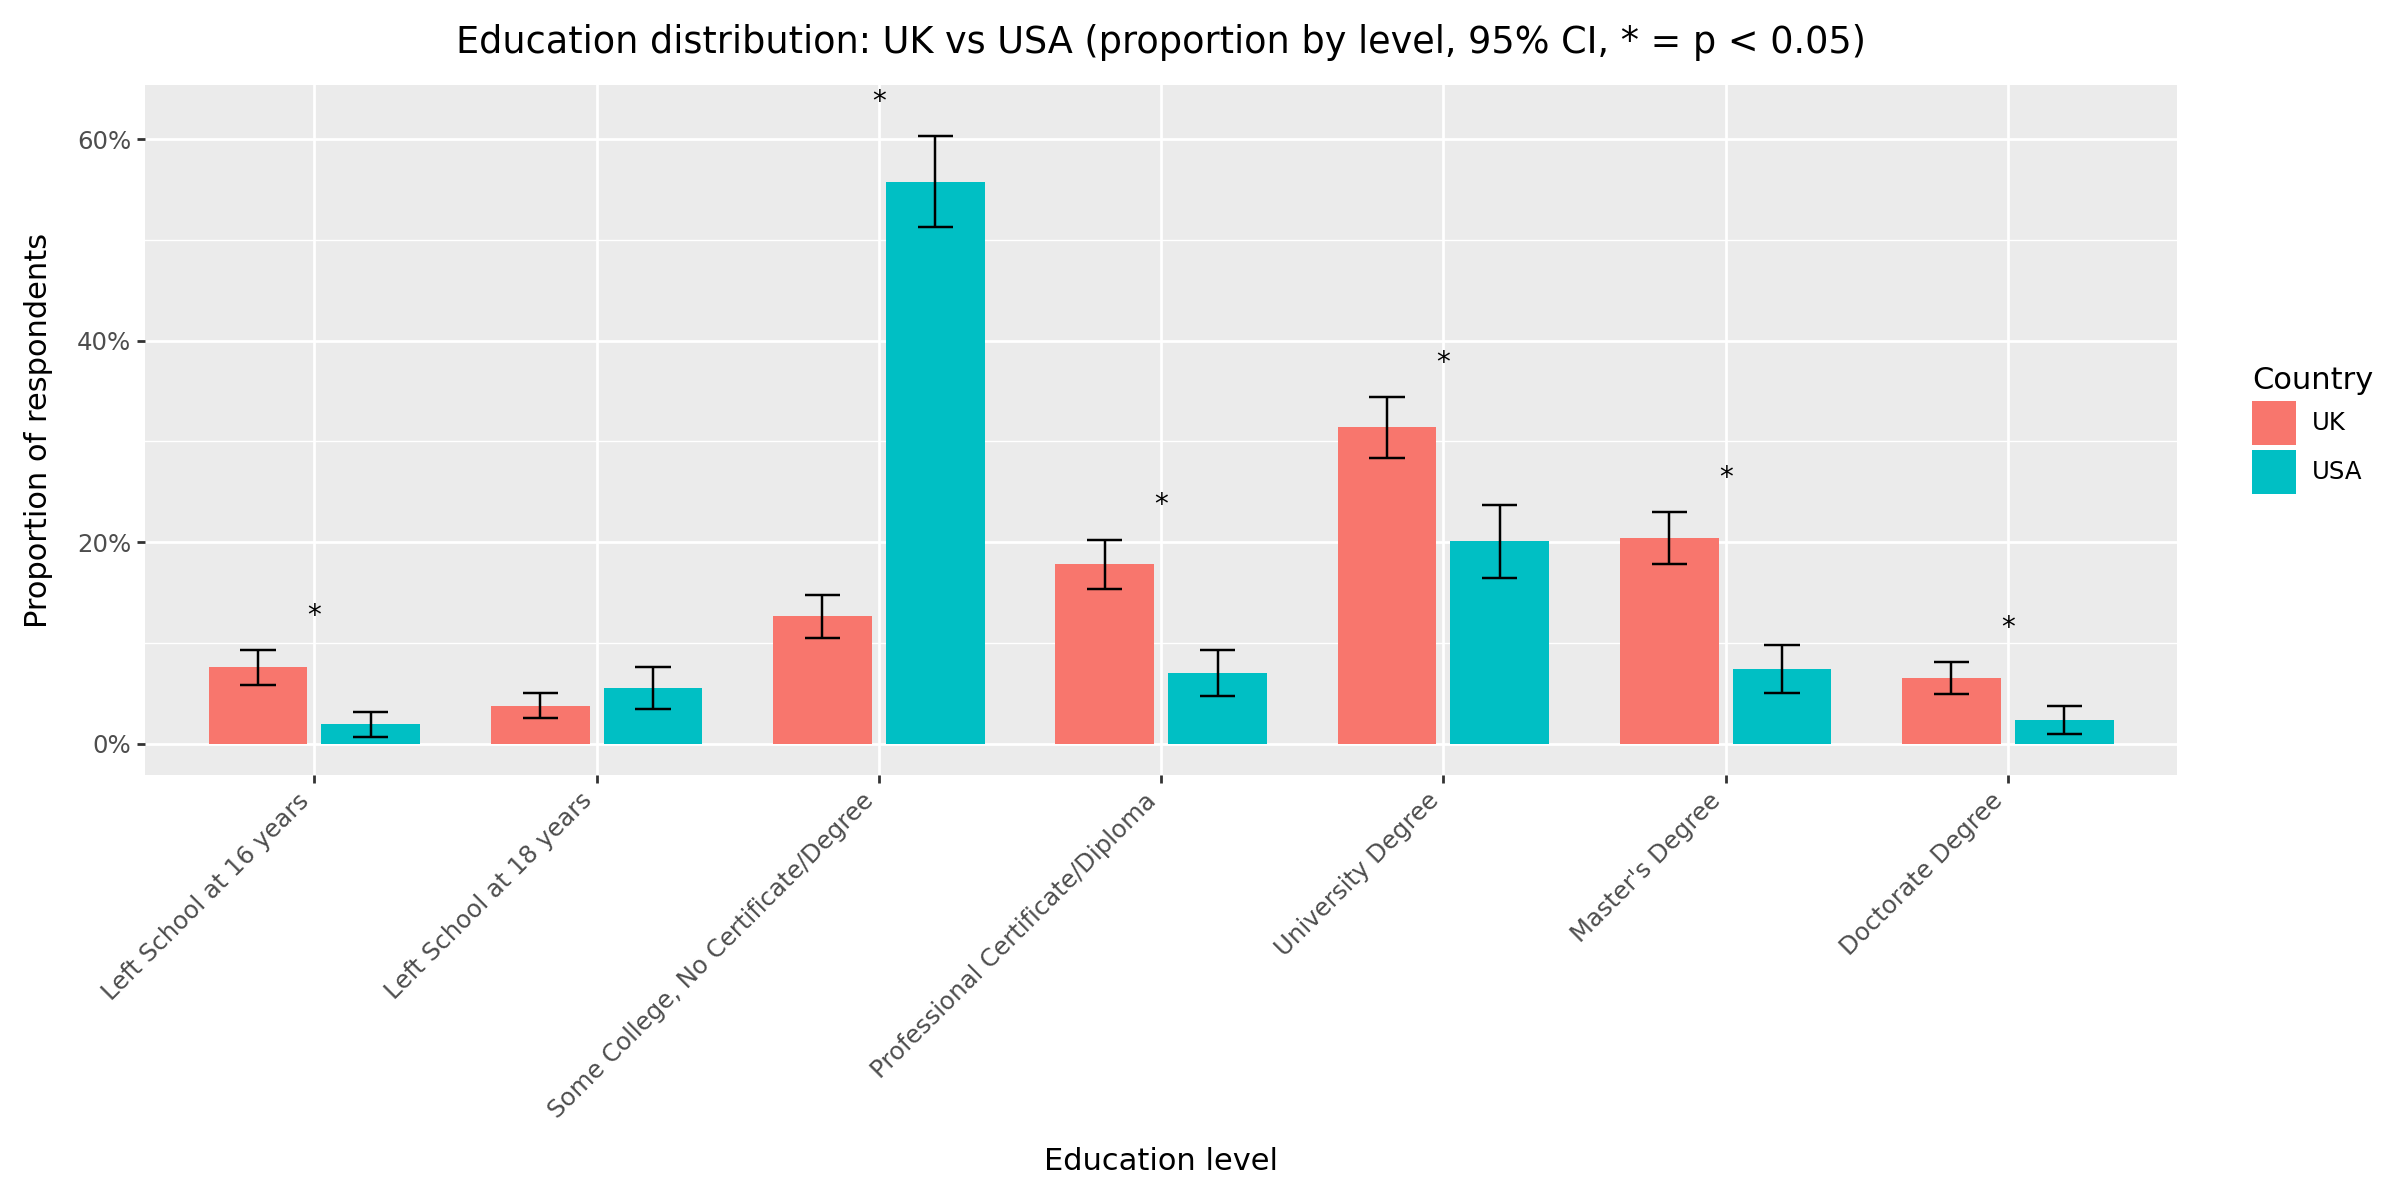

In [26]:
data_analysis.plot_edu_levels_country(data2)

Here we can see that there is a significant difference between educational distribution between the two countries. This should be accounted for when interpreting future results, that USA will skew education-related statistics, especially in college dropout area. It can be attributed to higher study and student costs in the USA, and the resulting high dropout rate. They also incur higher student debts, which can also drive them to use more drugs. So far, this is just speculation, but needs to be accounted for.

For next, lets visualize the usage of different drugs over different education levels.

In [27]:
drug_per_education = data_analysis.get_all_drug_usage_by_trait(human_readable_data, "Education")
#drug_per_education = drug_per_education[drug_per_education["Classifier"] != "Never Used"]
drug_per_education["Education"] = pd.Categorical(
        drug_per_education["Education"],
        categories=list(data_reading.EDUCATION.values()),
        ordered=True,
    )
drug_per_education_total = drug_per_education.copy()
drug_per_education_total

/home/rikkss/Documents/data-science-project/data_analysis.py:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


,Education,Drug,Classifier,Users
0,Left School at 16 years,Alcohol,Used in Last Day,18
1,Left School at 16 years,Alcohol,Used in Last Decade,5
2,Left School at 16 years,Alcohol,Used in Last Month,10
3,Left School at 16 years,Alcohol,Used in Last Week,30
4,Left School at 16 years,Alcohol,Used in Last Year,12
...,...,...,...,...
32,Master's Degree,VSA,Used in Last Year,2
33,Master's Degree,VSA,Used over a Decade Ago,17
34,Doctorate Degree,VSA,Never Used,56
35,Doctorate Degree,VSA,Used in Last Decade,1


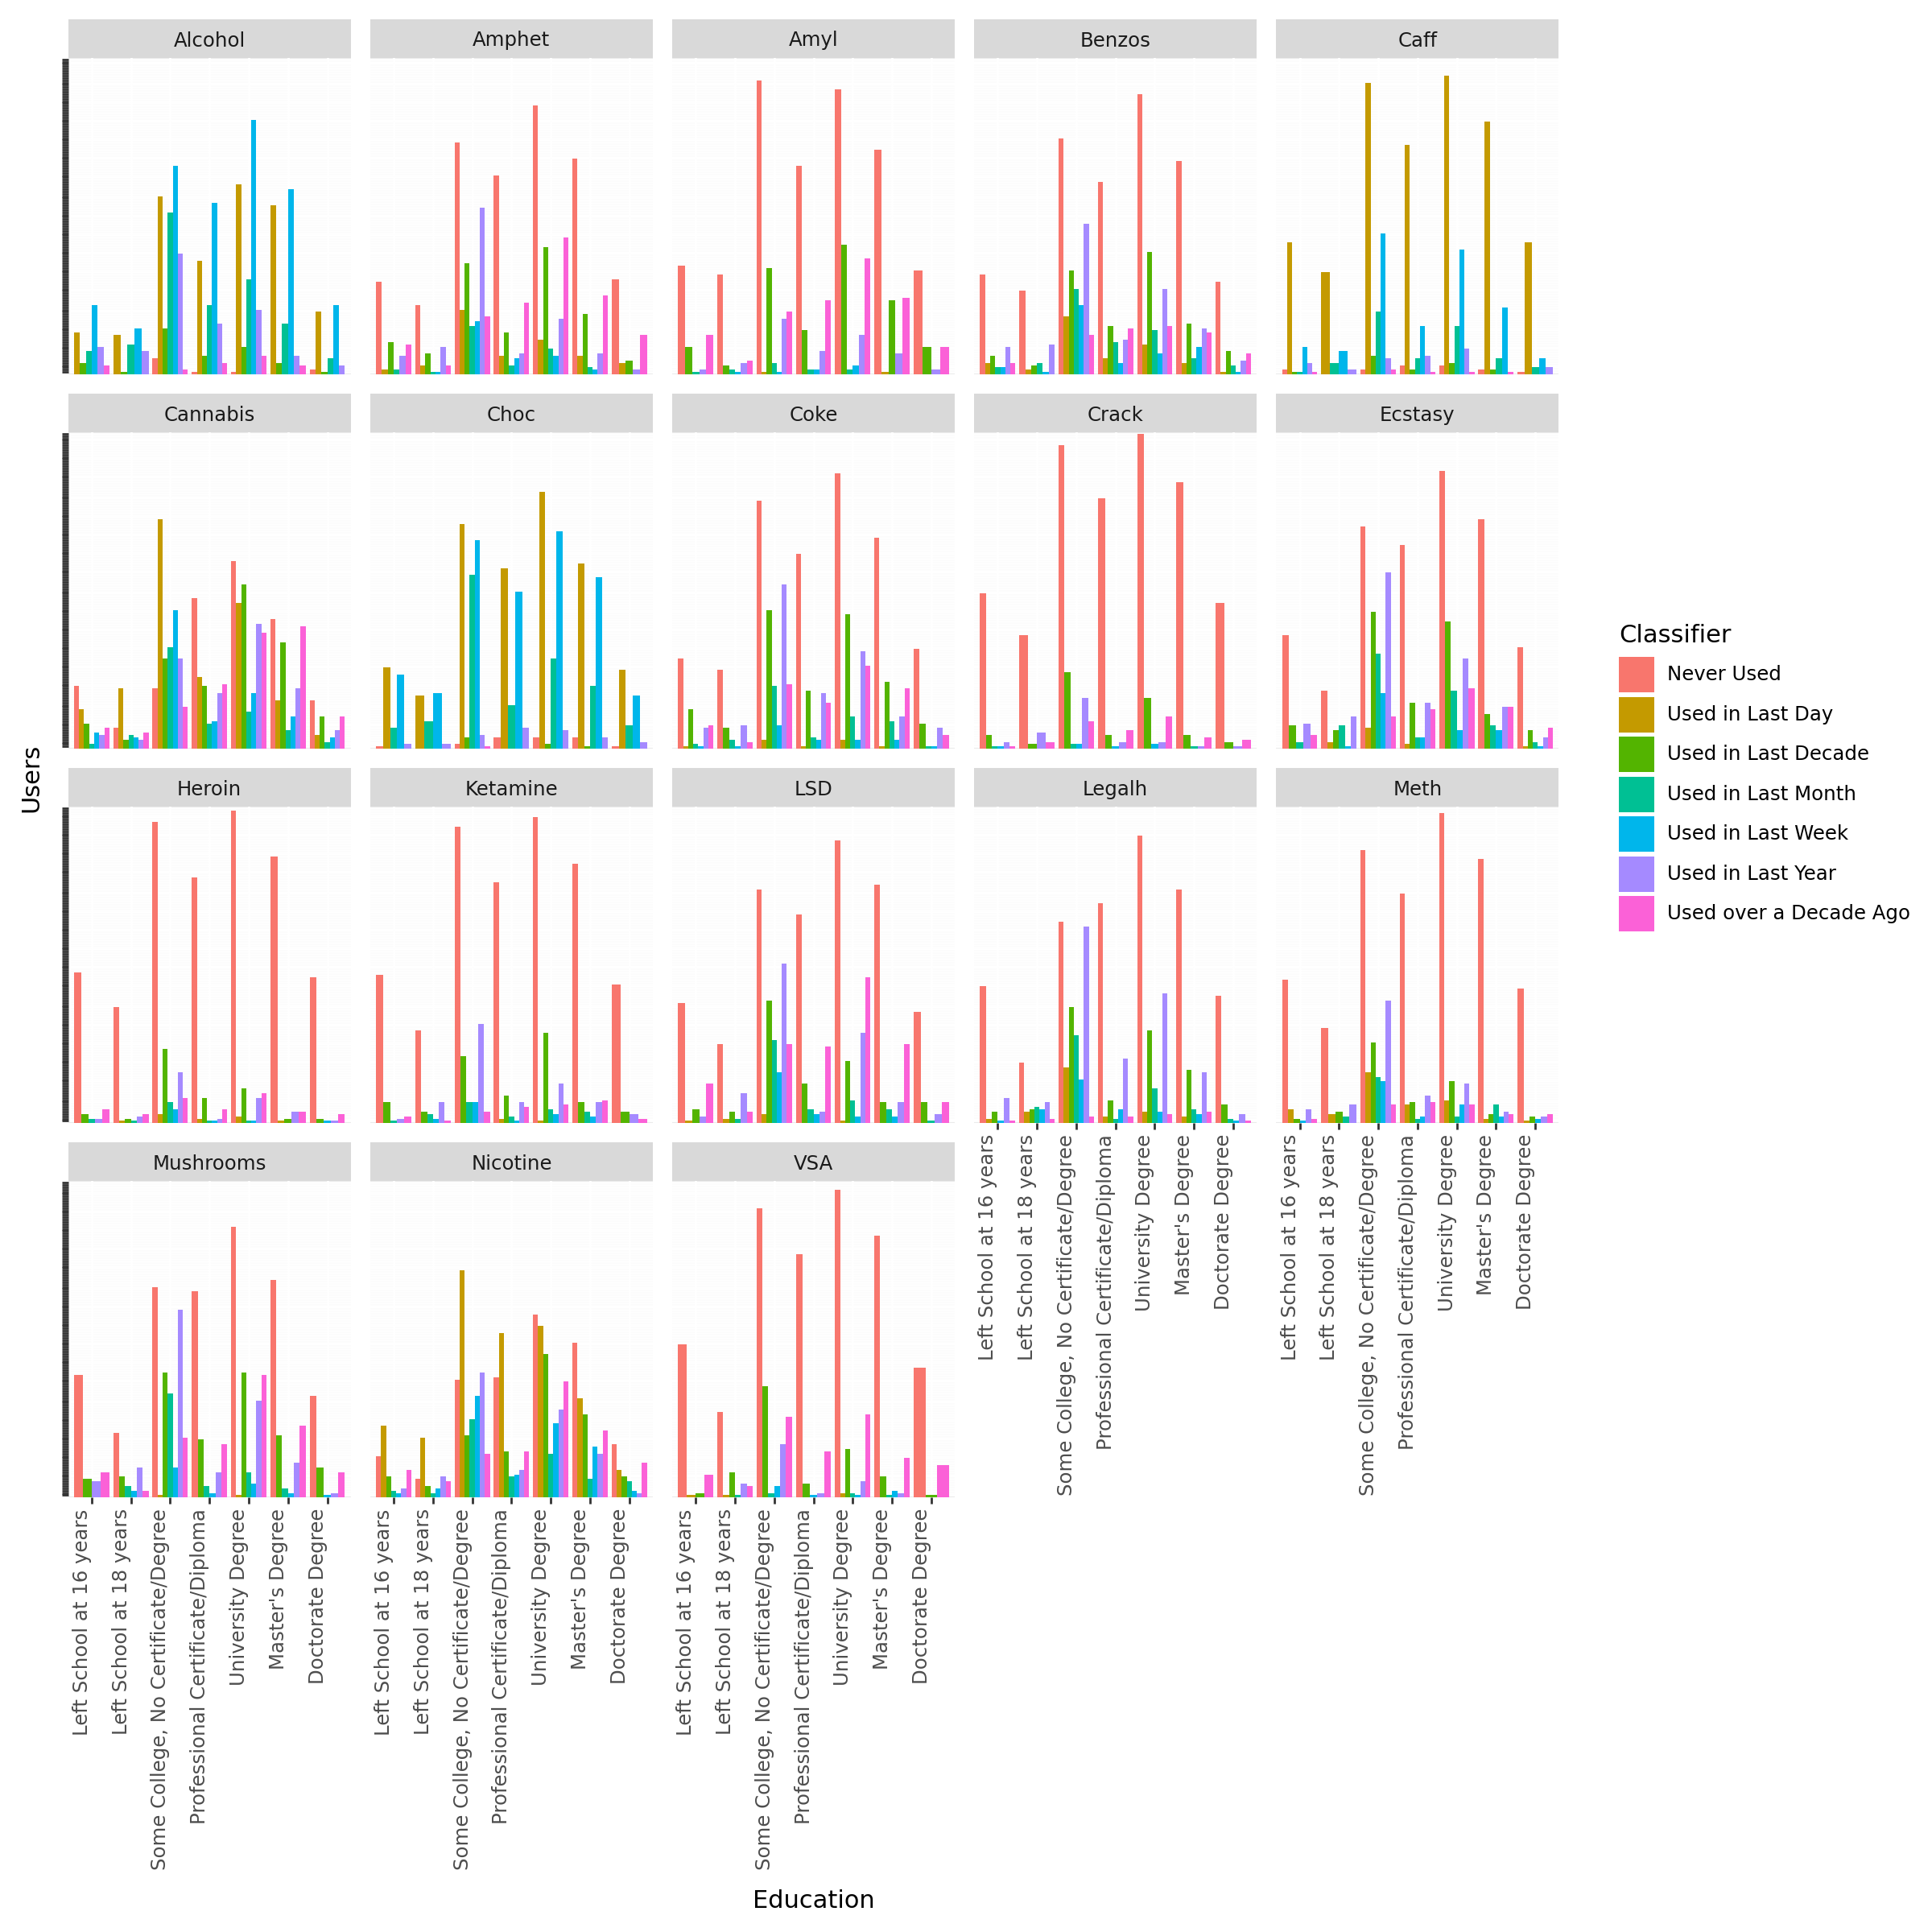

In [28]:
(
    pn.ggplot(drug_per_education, pn.aes("Education", "Users", fill="Classifier")) 
    + pn.geom_col(position="dodge")
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 12),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
        axis_text_y=pn.element_blank(),
    )
)

Taking into account the previously visualized amount of respondents per education level, the lower absolute number of users in lower education categories makes sense. Thus, those need to be visualized proportionally to respondents per education level. We will also drop ex-users (users, who haven't use the respective drugs for over a month) from the visualization, due to them mostly just cluttering it and making the visualization harder to read.

In [29]:
drug_per_education["Relative"] = drug_per_education["Users"] / drug_per_education.groupby(["Education", "Drug"], observed=True).transform("sum")["Users"]

/tmp/ipykernel_145756/2300365008.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


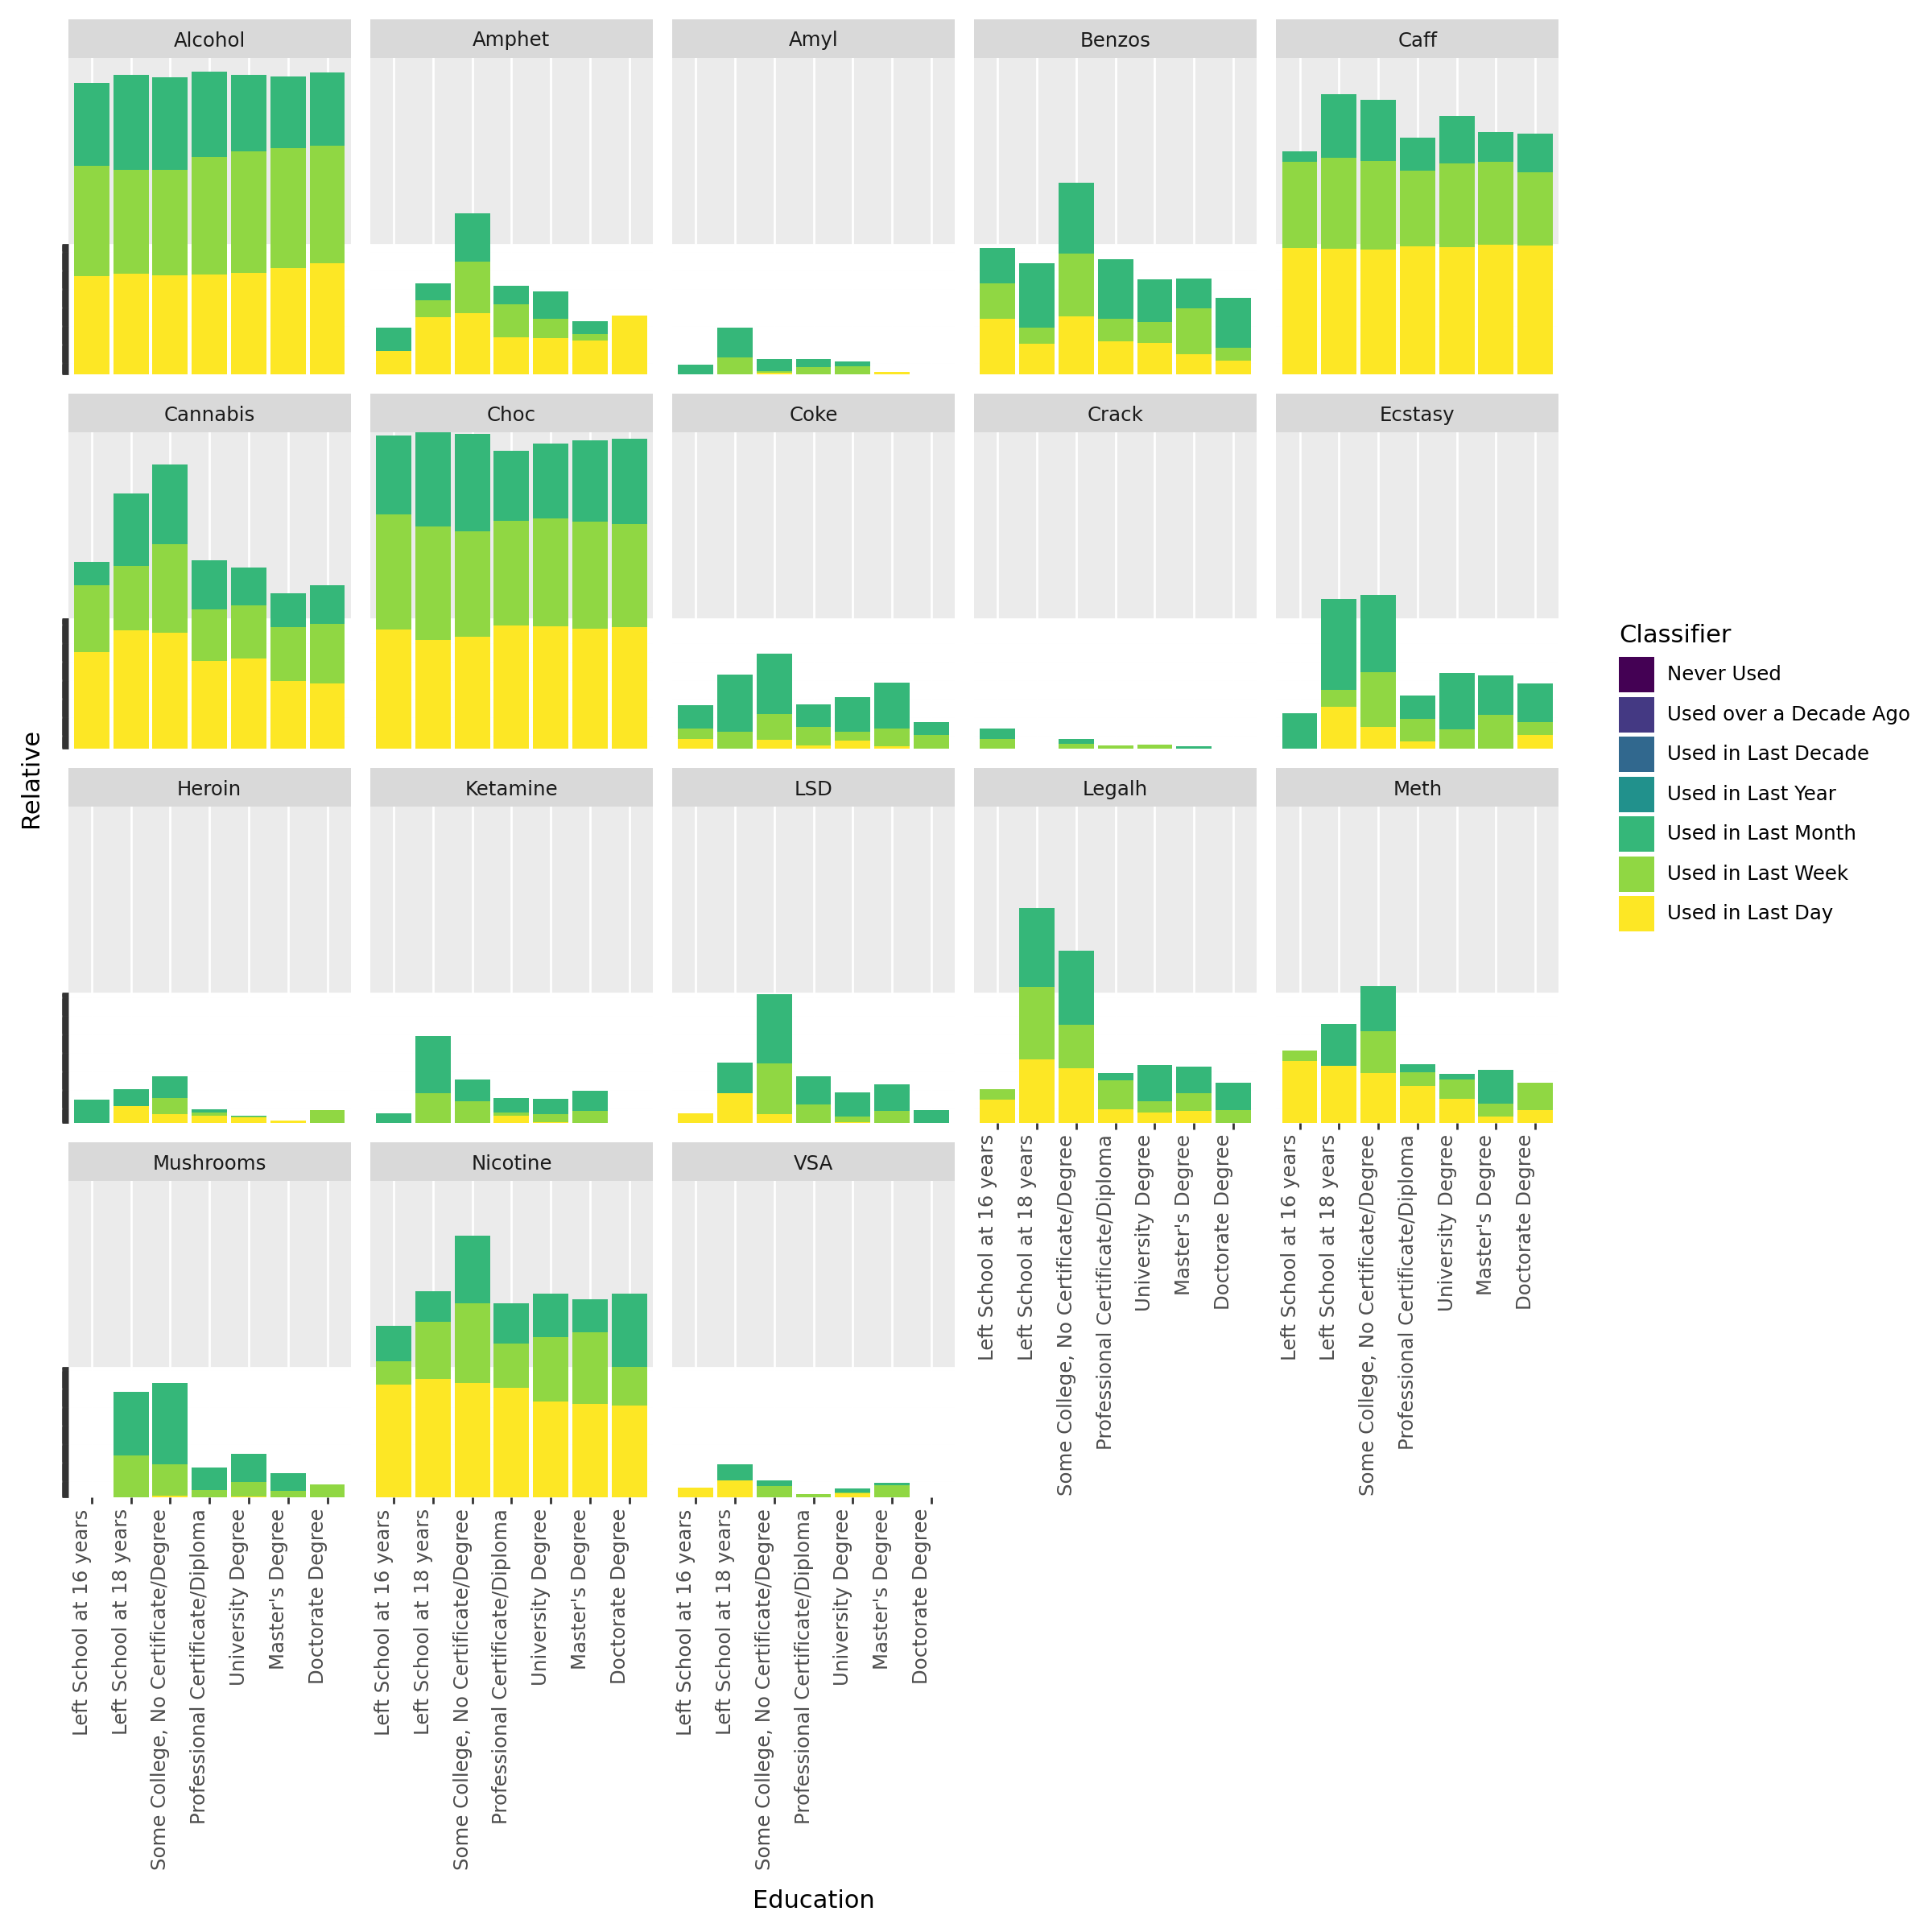

In [30]:
drug_per_education = drug_per_education[~drug_per_education["Classifier"].isin(["Never Used", "Used in Last Year", "Used over a Decade Ago", "Used in Last Decade"])]
drug_per_education["Classifier"] = pd.Categorical(
        drug_per_education["Classifier"],
        categories=list(data_reading.DRUG_CLASSIFIER.values()),
        ordered=True,
    )
(
    pn.ggplot(drug_per_education, pn.aes("Education", "Relative", fill="Classifier")) 
    + pn.geom_col()
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 12),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
        axis_text_y=pn.element_blank()
    )
)

As expected, **dropping out at college level increases drug usage rates** across the board. Similarly expected result is when dropping out at 18 years old. We expected that dropping out at younger ages would also increase the rates, but those seem to be consistent with gaining higher education.

## Drug Usage Rates by Other Metrics

### Drug Usage Rates by Gender

In [31]:
drug_per_gender = data_analysis.get_all_drug_usage_by_trait(human_readable_data, "Gender")
drug_per_gender["Relative"] = drug_per_gender["Users"] / drug_per_gender.groupby(["Gender", "Drug"], observed=True).transform("sum")["Users"]
drug_per_gender = drug_per_gender[~drug_per_gender["Classifier"].isin(
    ["Never Used", 
     "Used in Last Year", 
     "Used over a Decade Ago", 
     "Used in Last Decade"]
)]
drug_per_gender["Classifier"] = pd.Categorical(
        drug_per_gender["Classifier"],
        categories=list(data_reading.DRUG_CLASSIFIER.values()),
        ordered=True,
    )

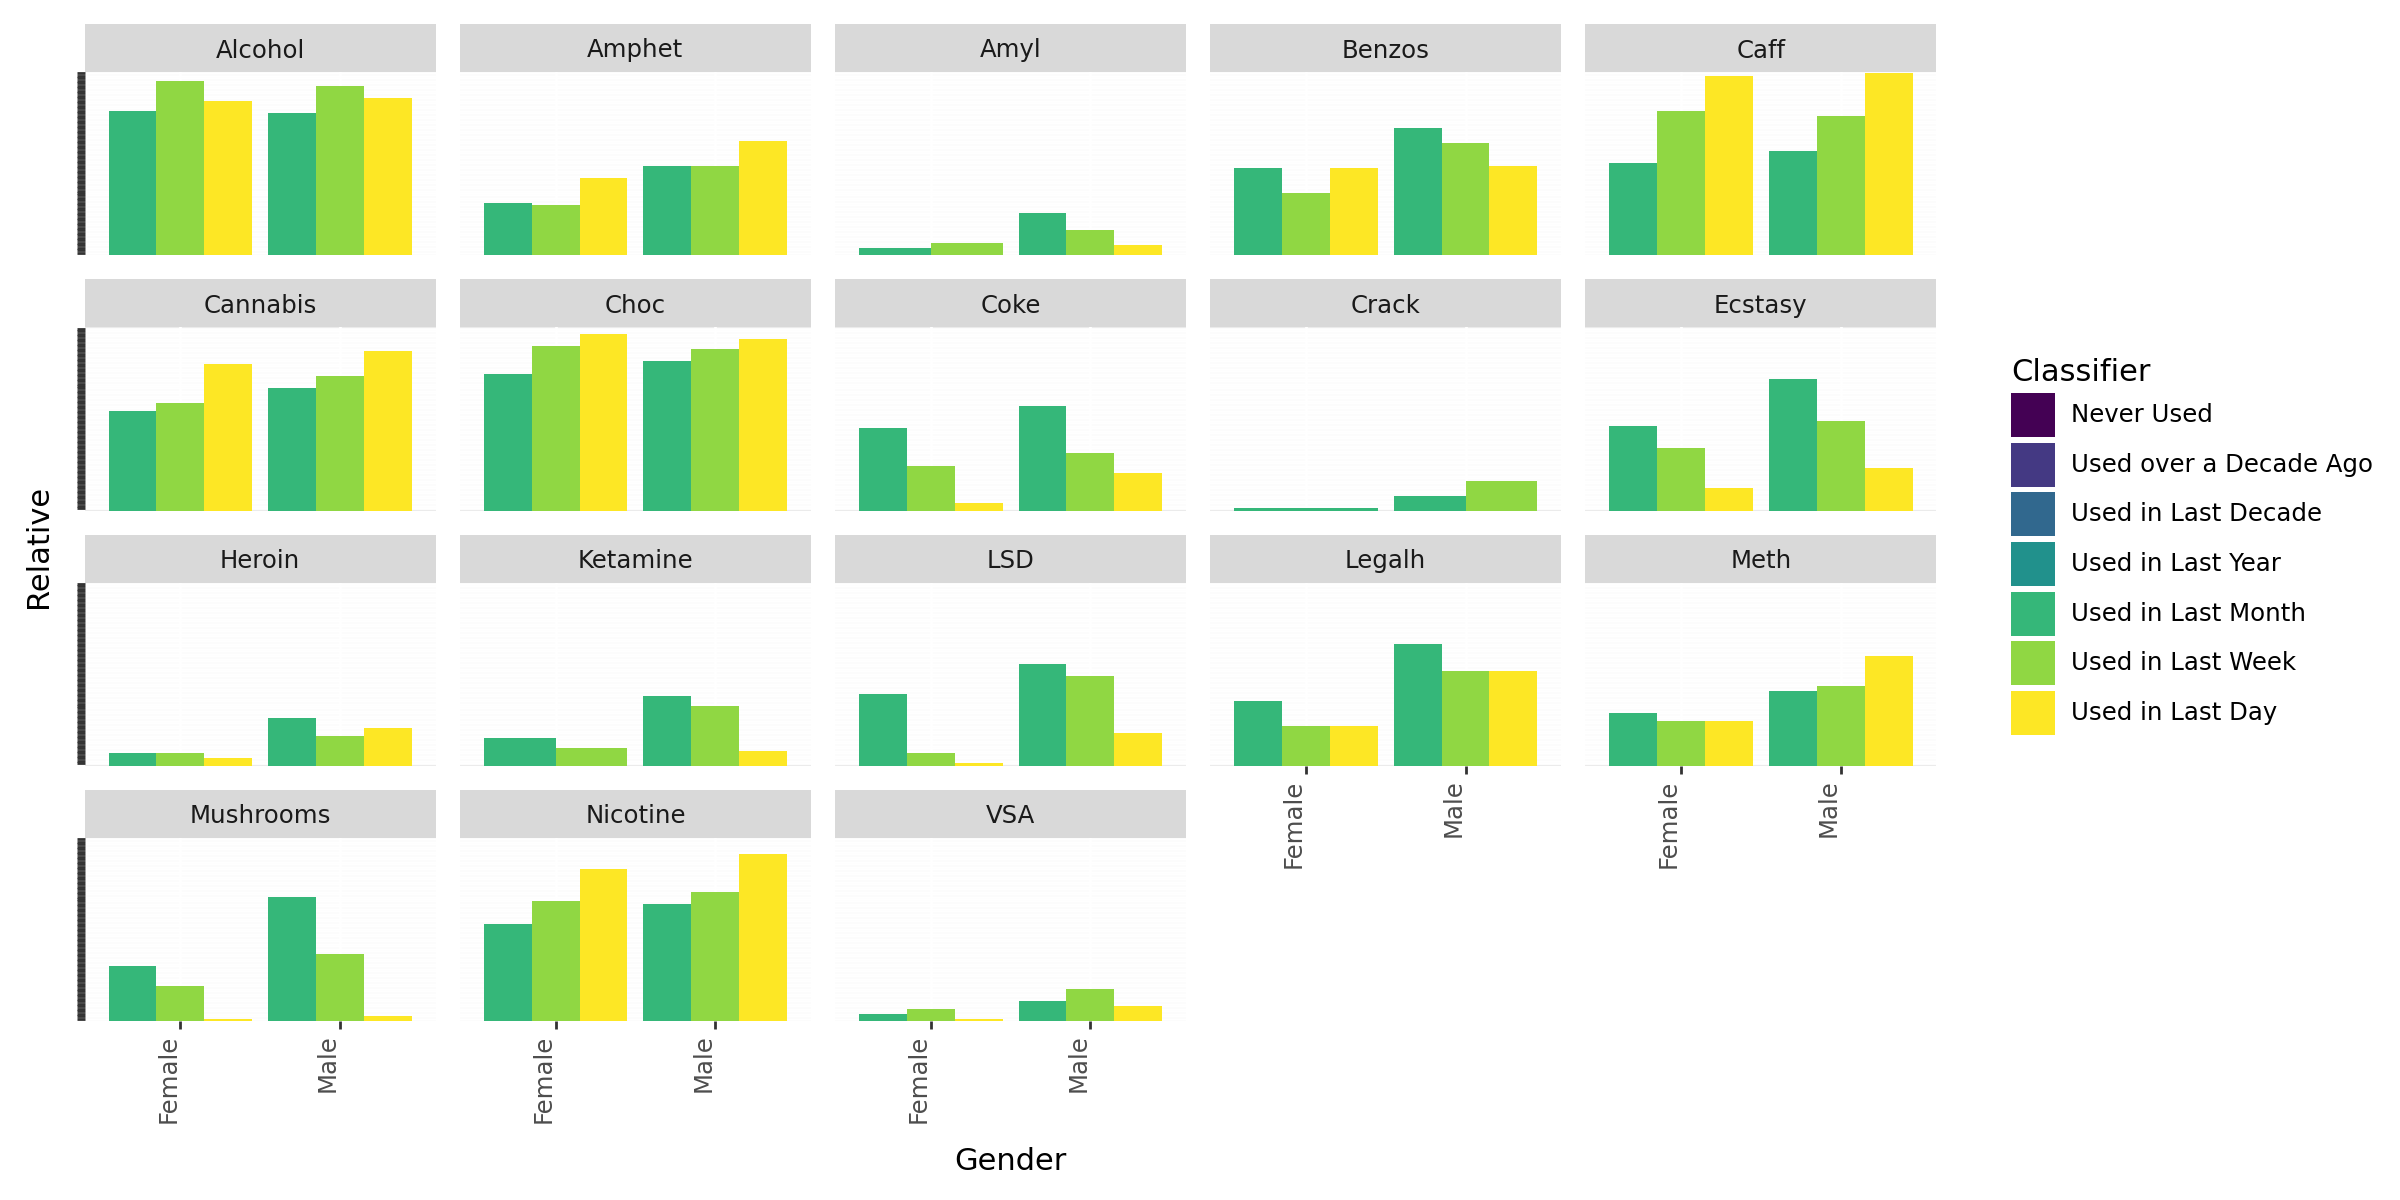

In [32]:
(
    pn.ggplot(drug_per_gender, pn.aes("Gender", "Relative", fill="Classifier")) 
    + pn.geom_col(position="dodge")
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 6),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
        axis_text_y=pn.element_blank(),
    )
)

These also seem to be in expected ranges based on other stides. Men tend to use more drugs than women, while legal drugs (Alcohol, Chocolate, Caffeine) seem to be about the same for both genders.

### Drug Usage by Age

In [33]:
drug_per_age = data_analysis.get_all_drug_usage_by_trait(human_readable_data, "Age")
drug_per_age["Relative"] = drug_per_age["Users"] / drug_per_age.groupby(["Age", "Drug"], observed=True).transform("sum")["Users"]
drug_per_age = drug_per_age[~drug_per_age["Classifier"].isin(
    ["Never Used", 
     "Used in Last Year", 
     "Used over a Decade Ago", 
     "Used in Last Decade"]
)]
drug_per_age["Classifier"] = pd.Categorical(
        drug_per_age["Classifier"],
        categories=list(data_reading.DRUG_CLASSIFIER.values()),
        ordered=True,
    )

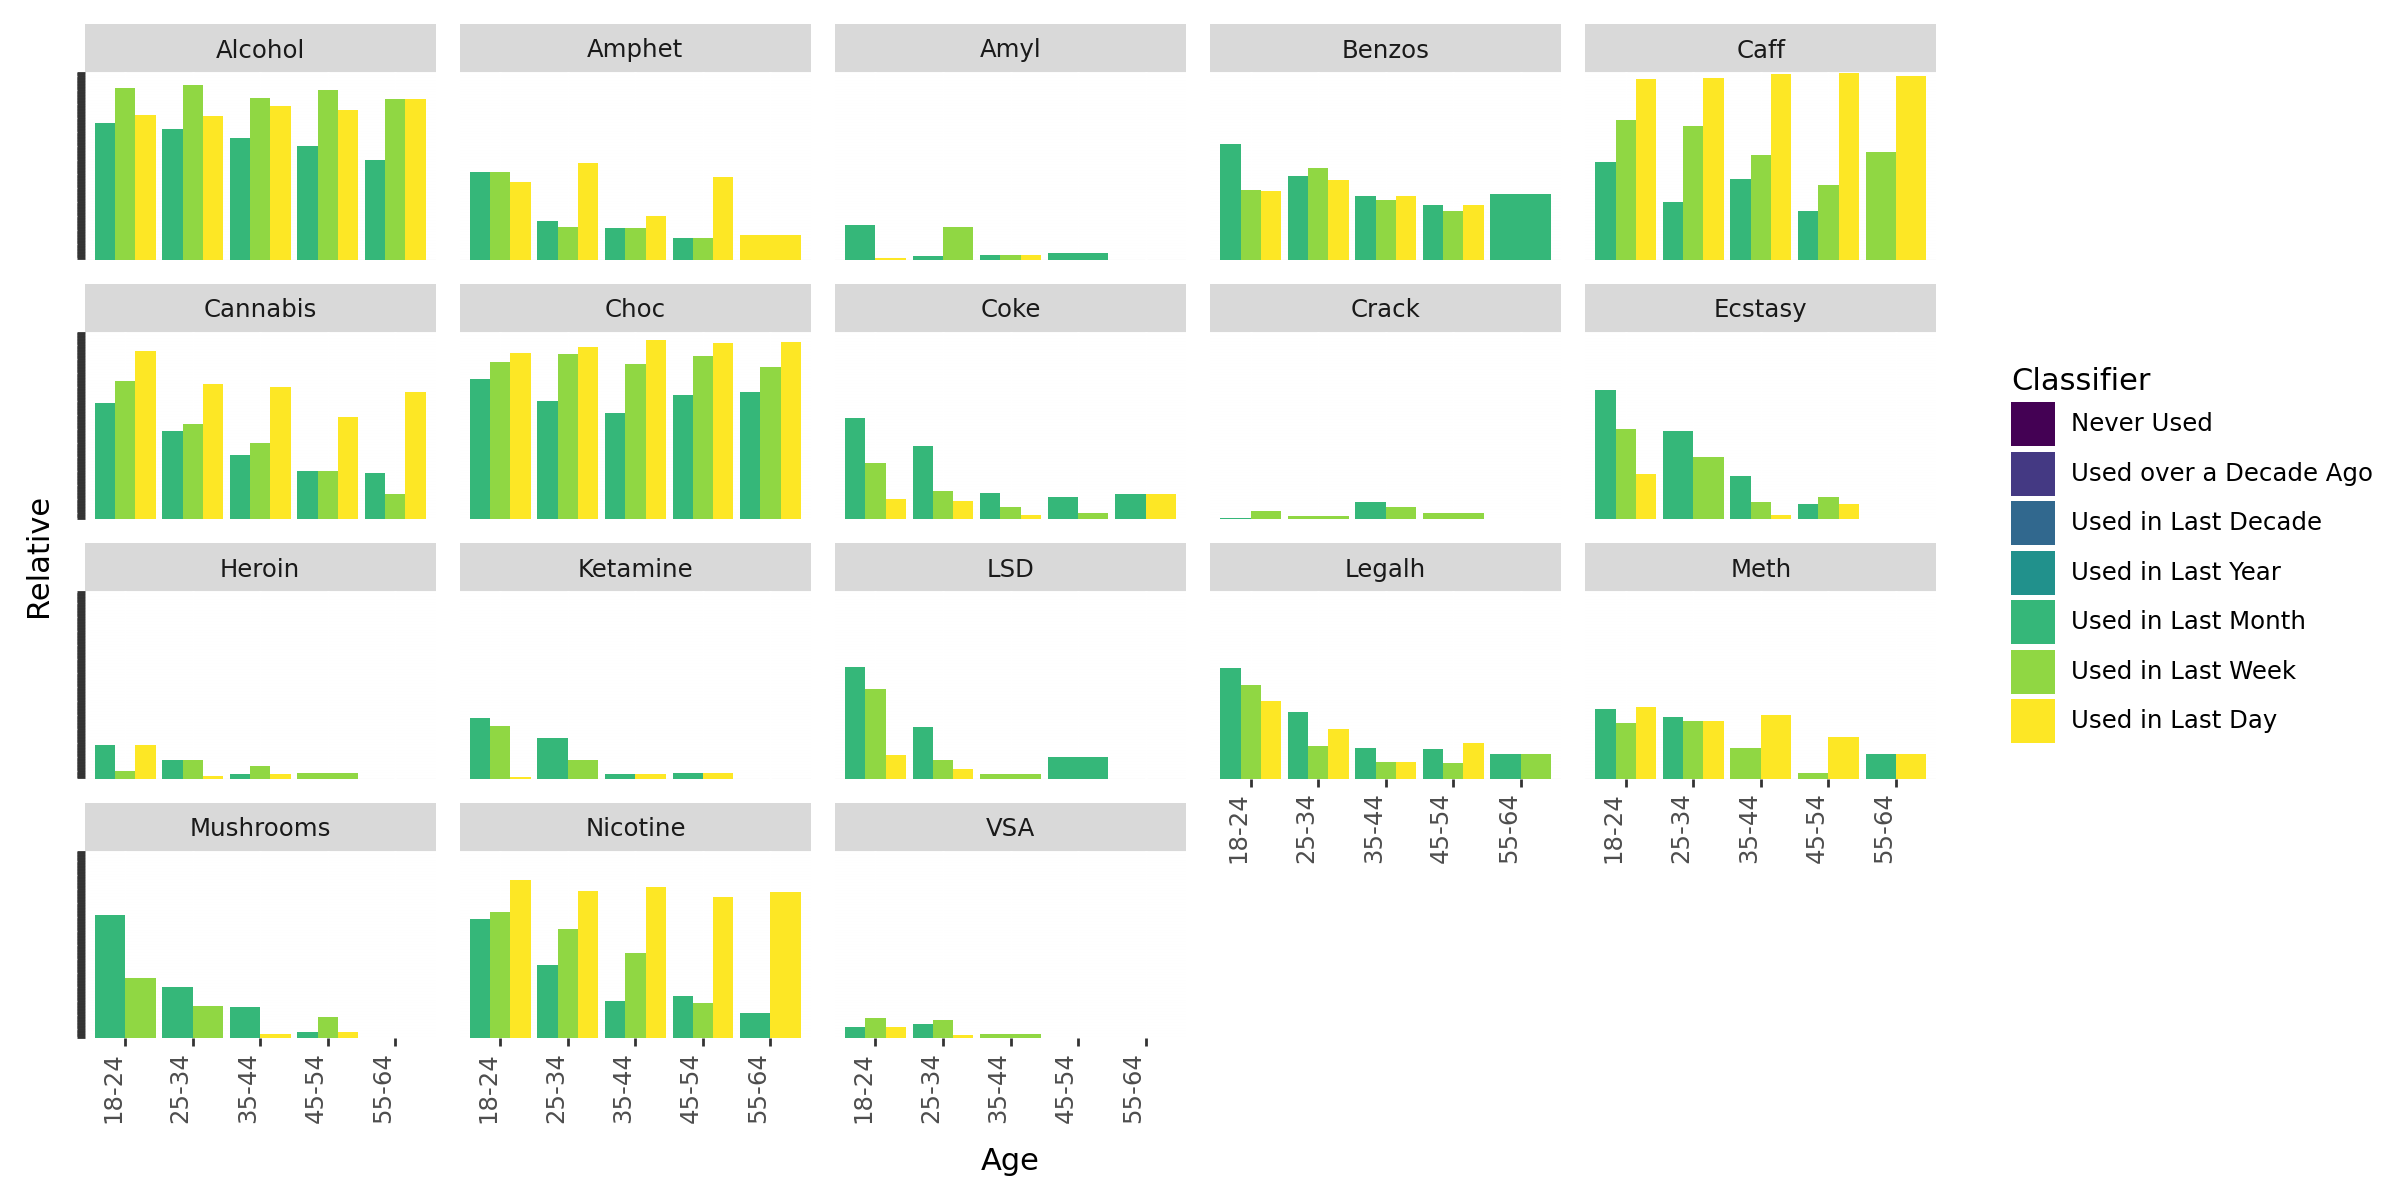

In [34]:
(
    pn.ggplot(drug_per_age, pn.aes("Age", "Relative", fill="Classifier")) 
    + pn.geom_col(position="dodge")
    + pn.facet_wrap("Drug")
    + pn.theme(
        figure_size=(12, 6),
        axis_text_x=pn.element_text(rotation=90, hjust=1),
        axis_text_y=pn.element_blank(),
    )
)

Also similarly expected, most of the drugs are used more by younger people, 34 and under. Similarly expected is that most people who use highly addictive drugs have used them within the last day.

## Drugs and Their Impact on Personality

Next lets see, if any of the drugs have a significant impact on the personality of their users. For that we will calculate the mean values per each drug for each measured personality trait, and then plot them on a graph. We will also calculate, if their difference is large enough to be considered statistically significant for the impact on their user's personality.

In [35]:
personality_drugs = human_readable_data[data_reading.DRUG_TYPES + data_reading.PERSONALITY_TRAITS]
melted_drugs = personality_drugs.melt(
    id_vars=data_reading.DRUG_TYPES,
    value_vars=data_reading.PERSONALITY_TRAITS,
    var_name="Trait",
    value_name="Score",
)


melted_drugs = data_analysis.get_personality_drug_melt(melted_drugs)

# Exclude non-users of the drugs for calculations
mean_scores = data_analysis.calculate_mean_personality_scores_per_drug(melted_drugs[melted_drugs["Classifier"] != "Never Used"])


/home/rikkss/Documents/data-science-project/data_analysis.py:133: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
/home/rikkss/Documents/data-science-project/data_analysis.py:142: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


Lets add in overall mean values for each personality trait into the DataFrame.

In [36]:
# Insert overall means for each trait
mean_scores = data_analysis.calculate_overall_personality_means(melted_drugs, mean_scores)

Check, if any CI scores and mean differences are to be considered significant enough to be categorized as such.

In [37]:
mean_scores = data_analysis.calculate_significant_difference_from_overall(mean_scores)

Visualize the calculations

In [38]:
ascores = mean_scores[mean_scores["Trait"] == "Ascore"]
cscores = mean_scores[mean_scores["Trait"] == "Cscore"]
escores = mean_scores[mean_scores["Trait"] == "Escore"]
impulsive = mean_scores[mean_scores["Trait"] == "Impulsive"]
nscores = mean_scores[mean_scores["Trait"] == "Nscore"]
oscores = mean_scores[mean_scores["Trait"] == "Oscore"]
ss = mean_scores[mean_scores["Trait"] == "SS"]

type_colors = {
    "Significant Difference": "#cc3300",  # red
    "Within Bounds": "#88cc00",           # green
    "Overall mean": "#00cccc"             # blue
}

def pn_config(data, trait, ylim=(37,43.5)):
    return (
        pn.ggplot(data, pn.aes("reorder(Drug, Score)", "Score", fill="Type")) 
        + pn.geom_col()
        + pn.theme(
            figure_size=(12, 6),
            axis_text_x=pn.element_text(rotation=30, hjust=1),
            axis_text_y=pn.element_blank(),
            legend_position="none",
            
        )
        + pn.coord_cartesian(ylim=ylim)
        + pn.labs(x="", y=trait, title=f"{trait} by Drug")
        + pn.geom_errorbar(
            pn.aes(ymin="CI_low", ymax="CI_high"),
            width=0.2
        )
        + pn.scale_fill_manual(values=type_colors)
    )

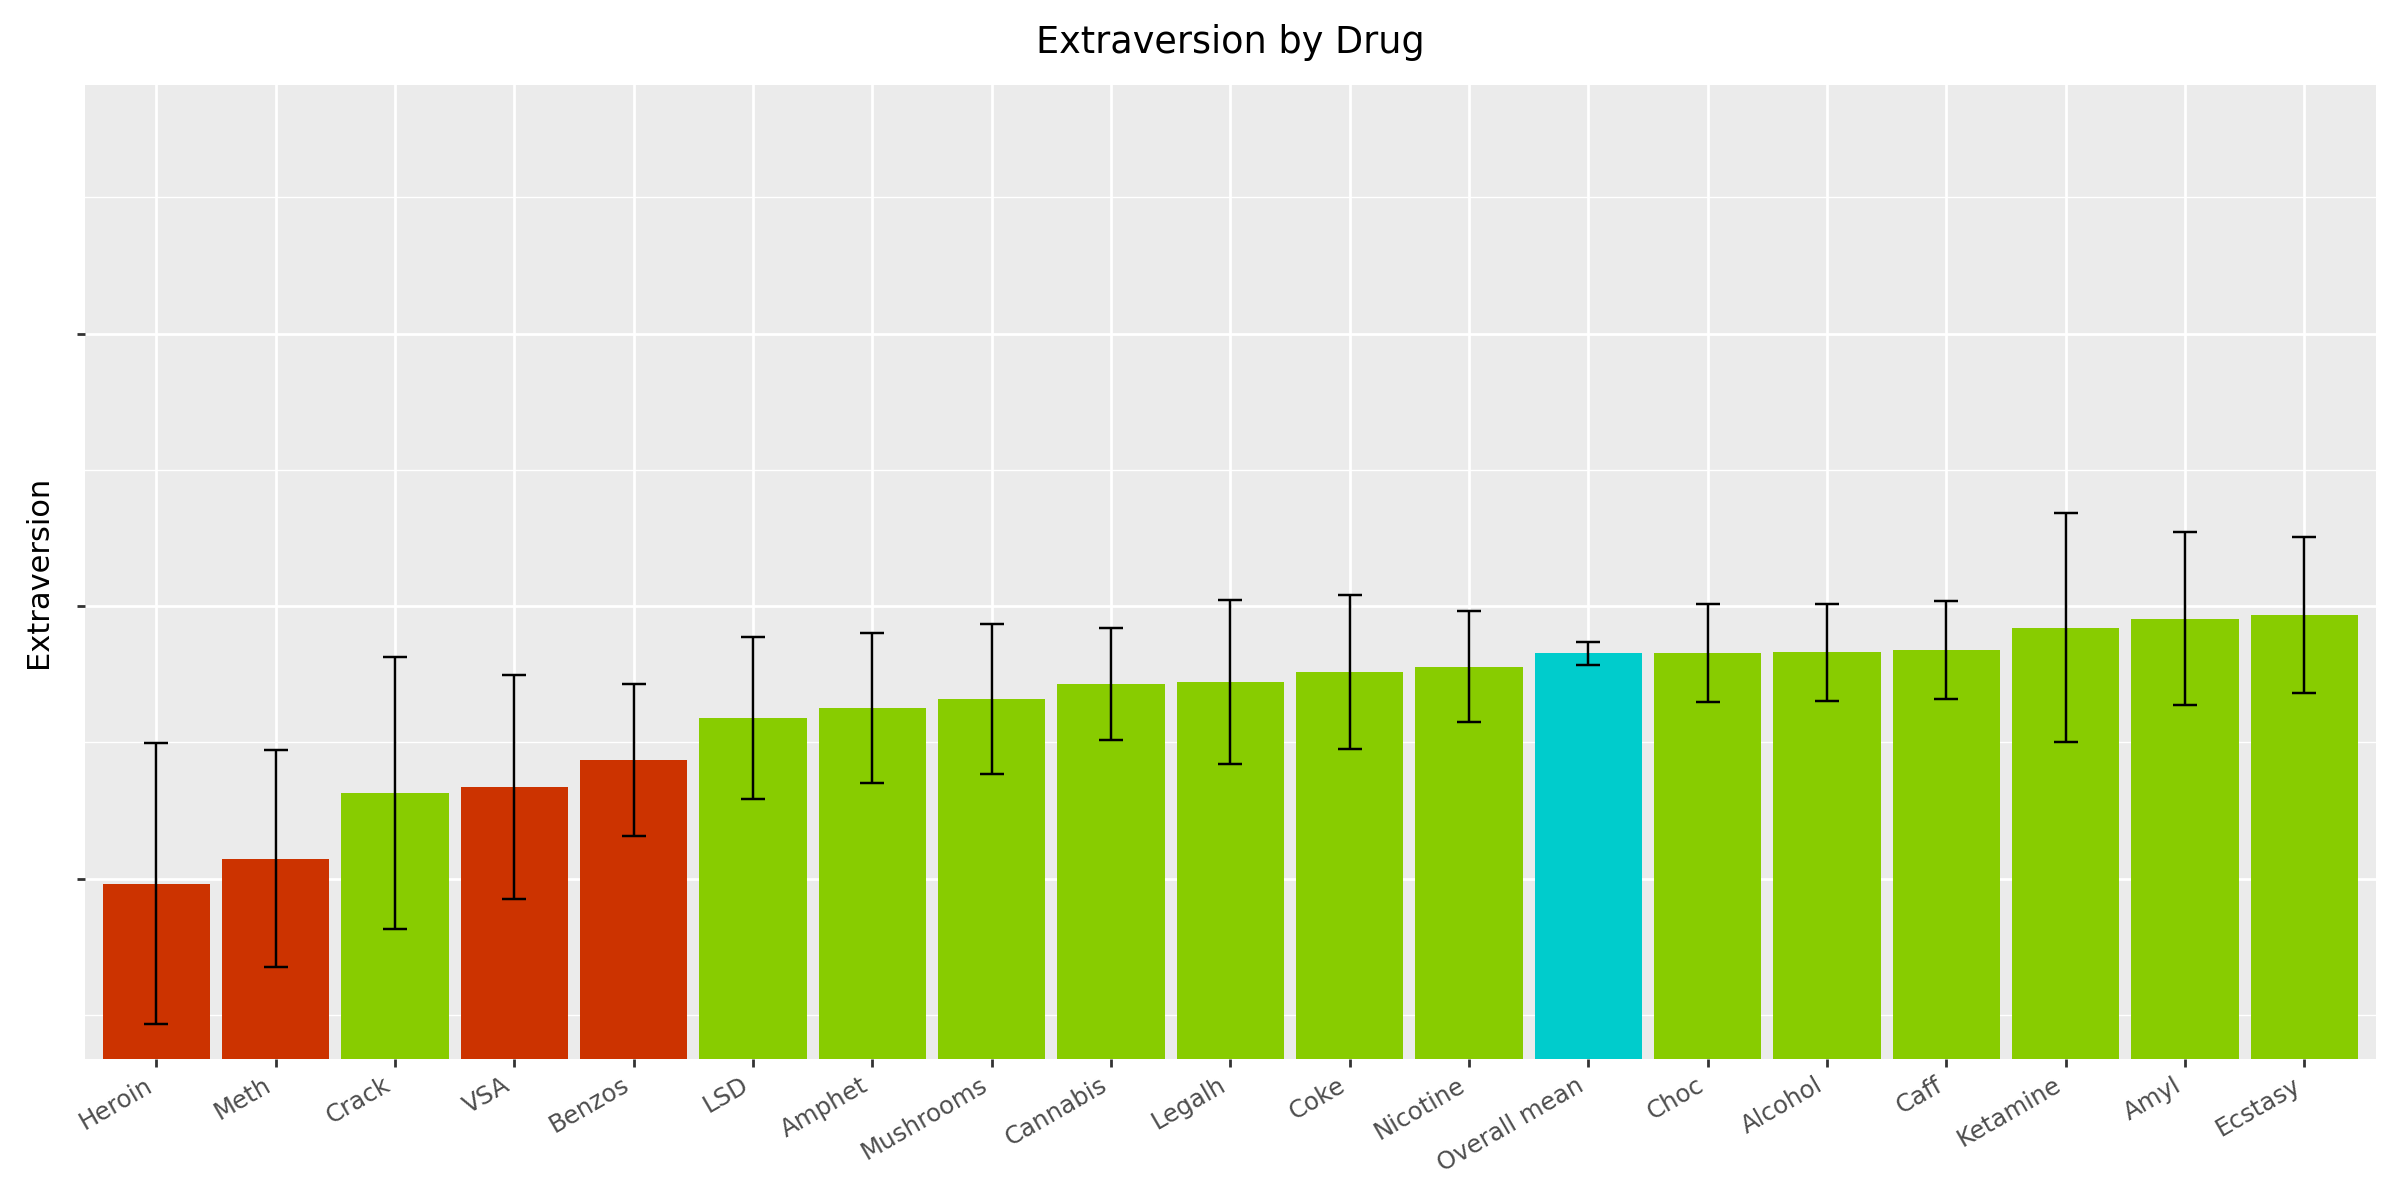

In [39]:
pn_config(escores, "Extraversion")

Here we can confidently say, that extraversion doesn't get impacted too much by given drugs based on this dataset. We see that **Heroin, Meth, VSA and Benzos** are barely outside of the overall mean, with large errors. Based on current observations, we could say it is significant enough, but low confidence indicators also show, that it might not be the case.

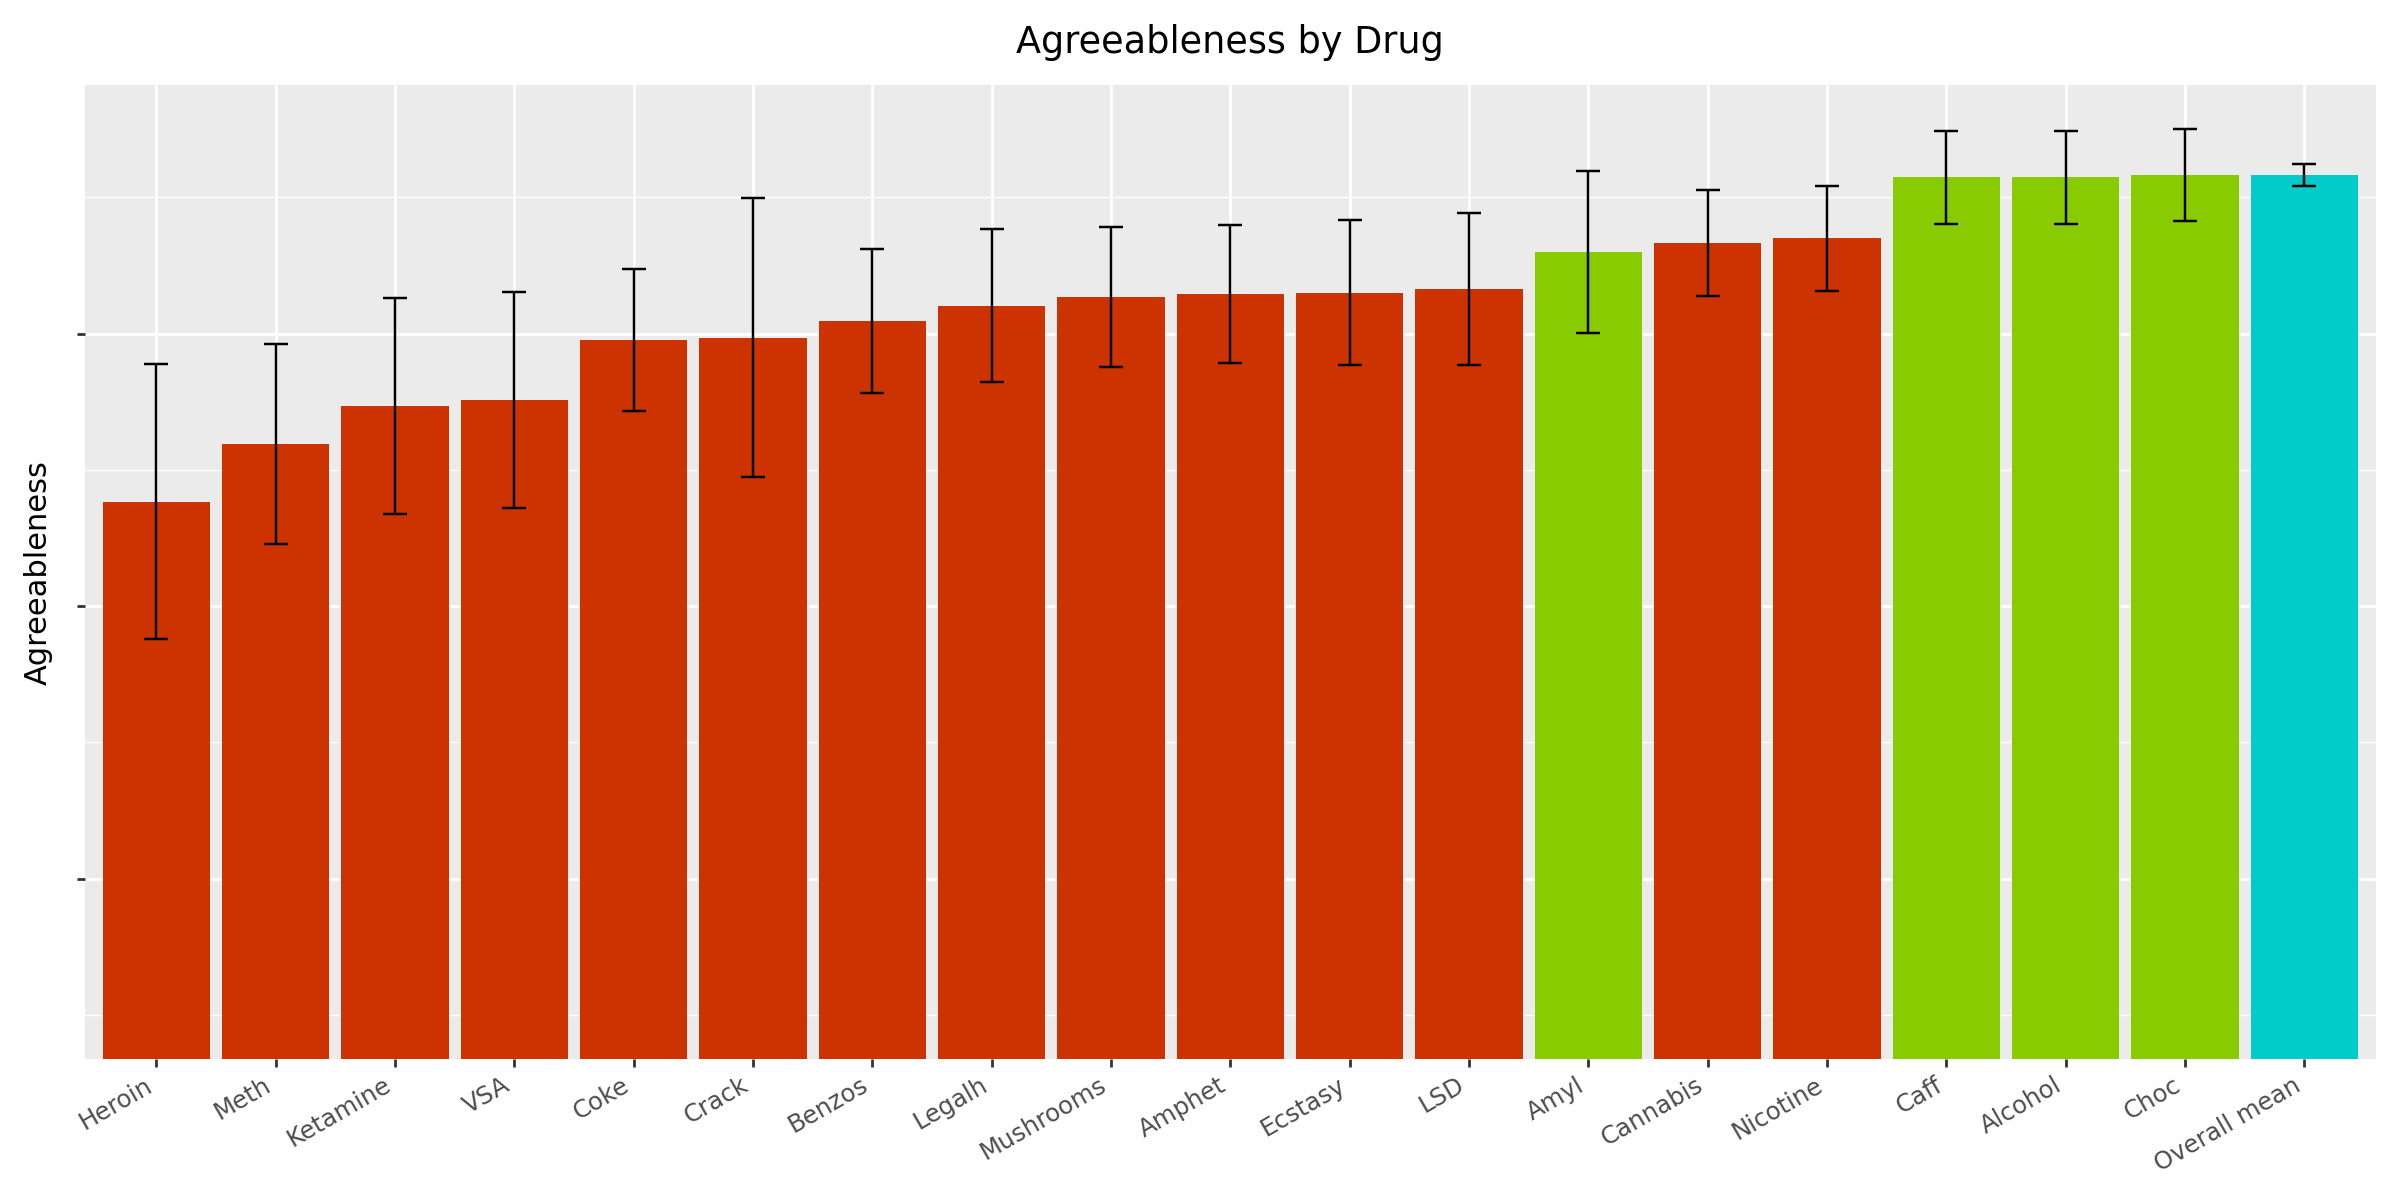

In [40]:
pn_config(ascores, "Agreeableness")

We can easily observe here, that **Agreeableness is heavily impacted by drugs**. Most drugs reduce it, and harder drugs, especially **Heroin, Methamphetamines, and Cocaine** reduce agreeableness by a lot.

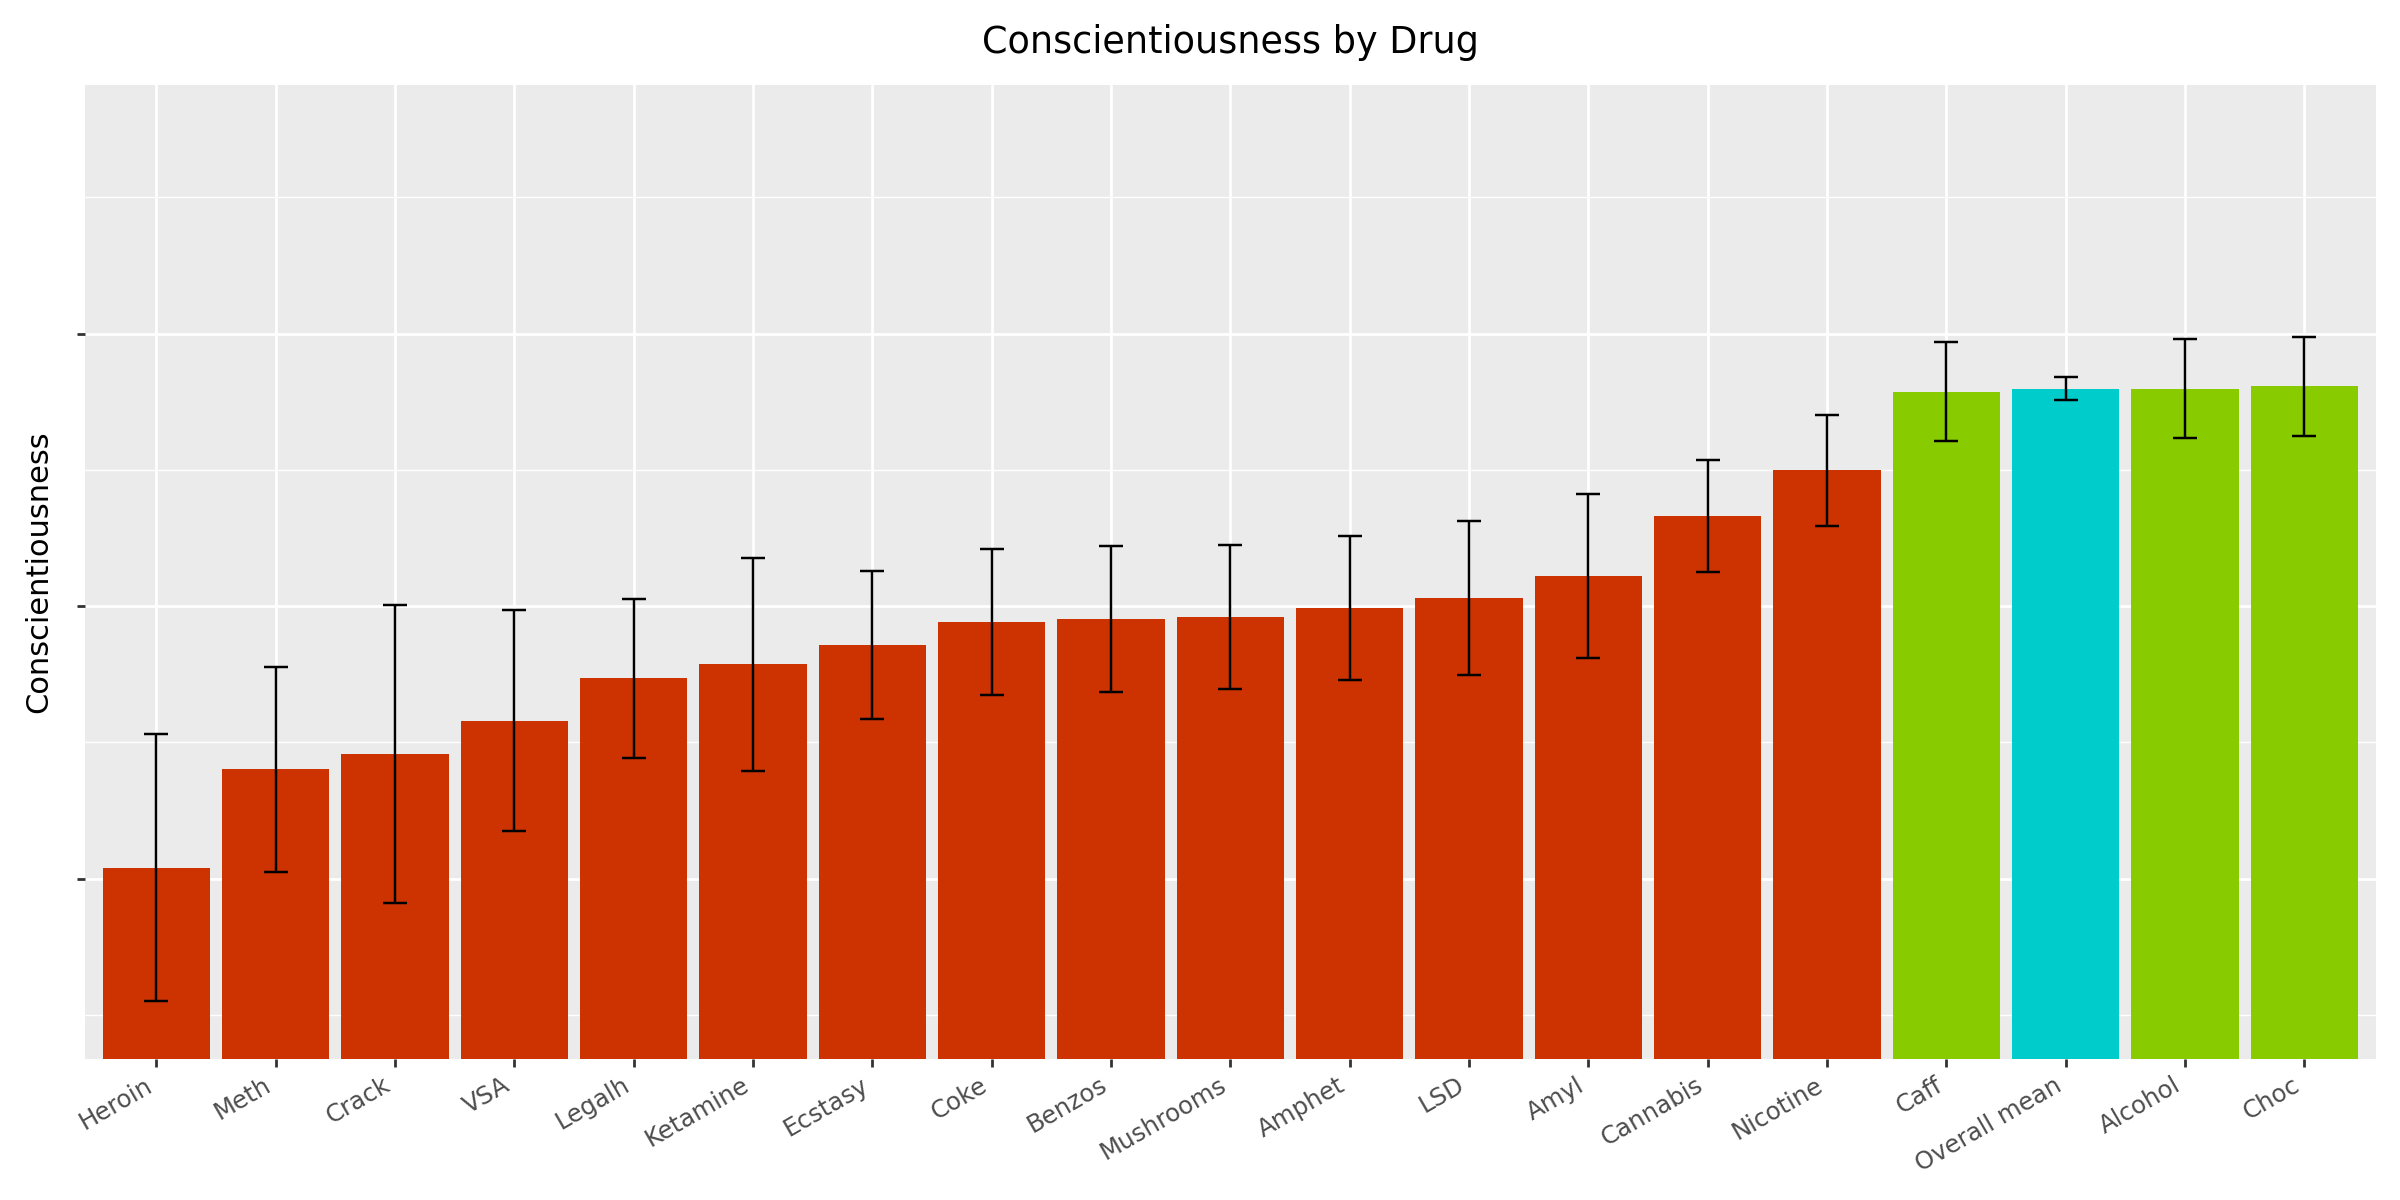

In [41]:
pn_config(cscores, "Conscientiousness")

What goes for Agreeableness, goes doubly for Conscientiousness. **Conscientiousness** is very heavily impacted by various drugs, making the users less structured and less organized overall.

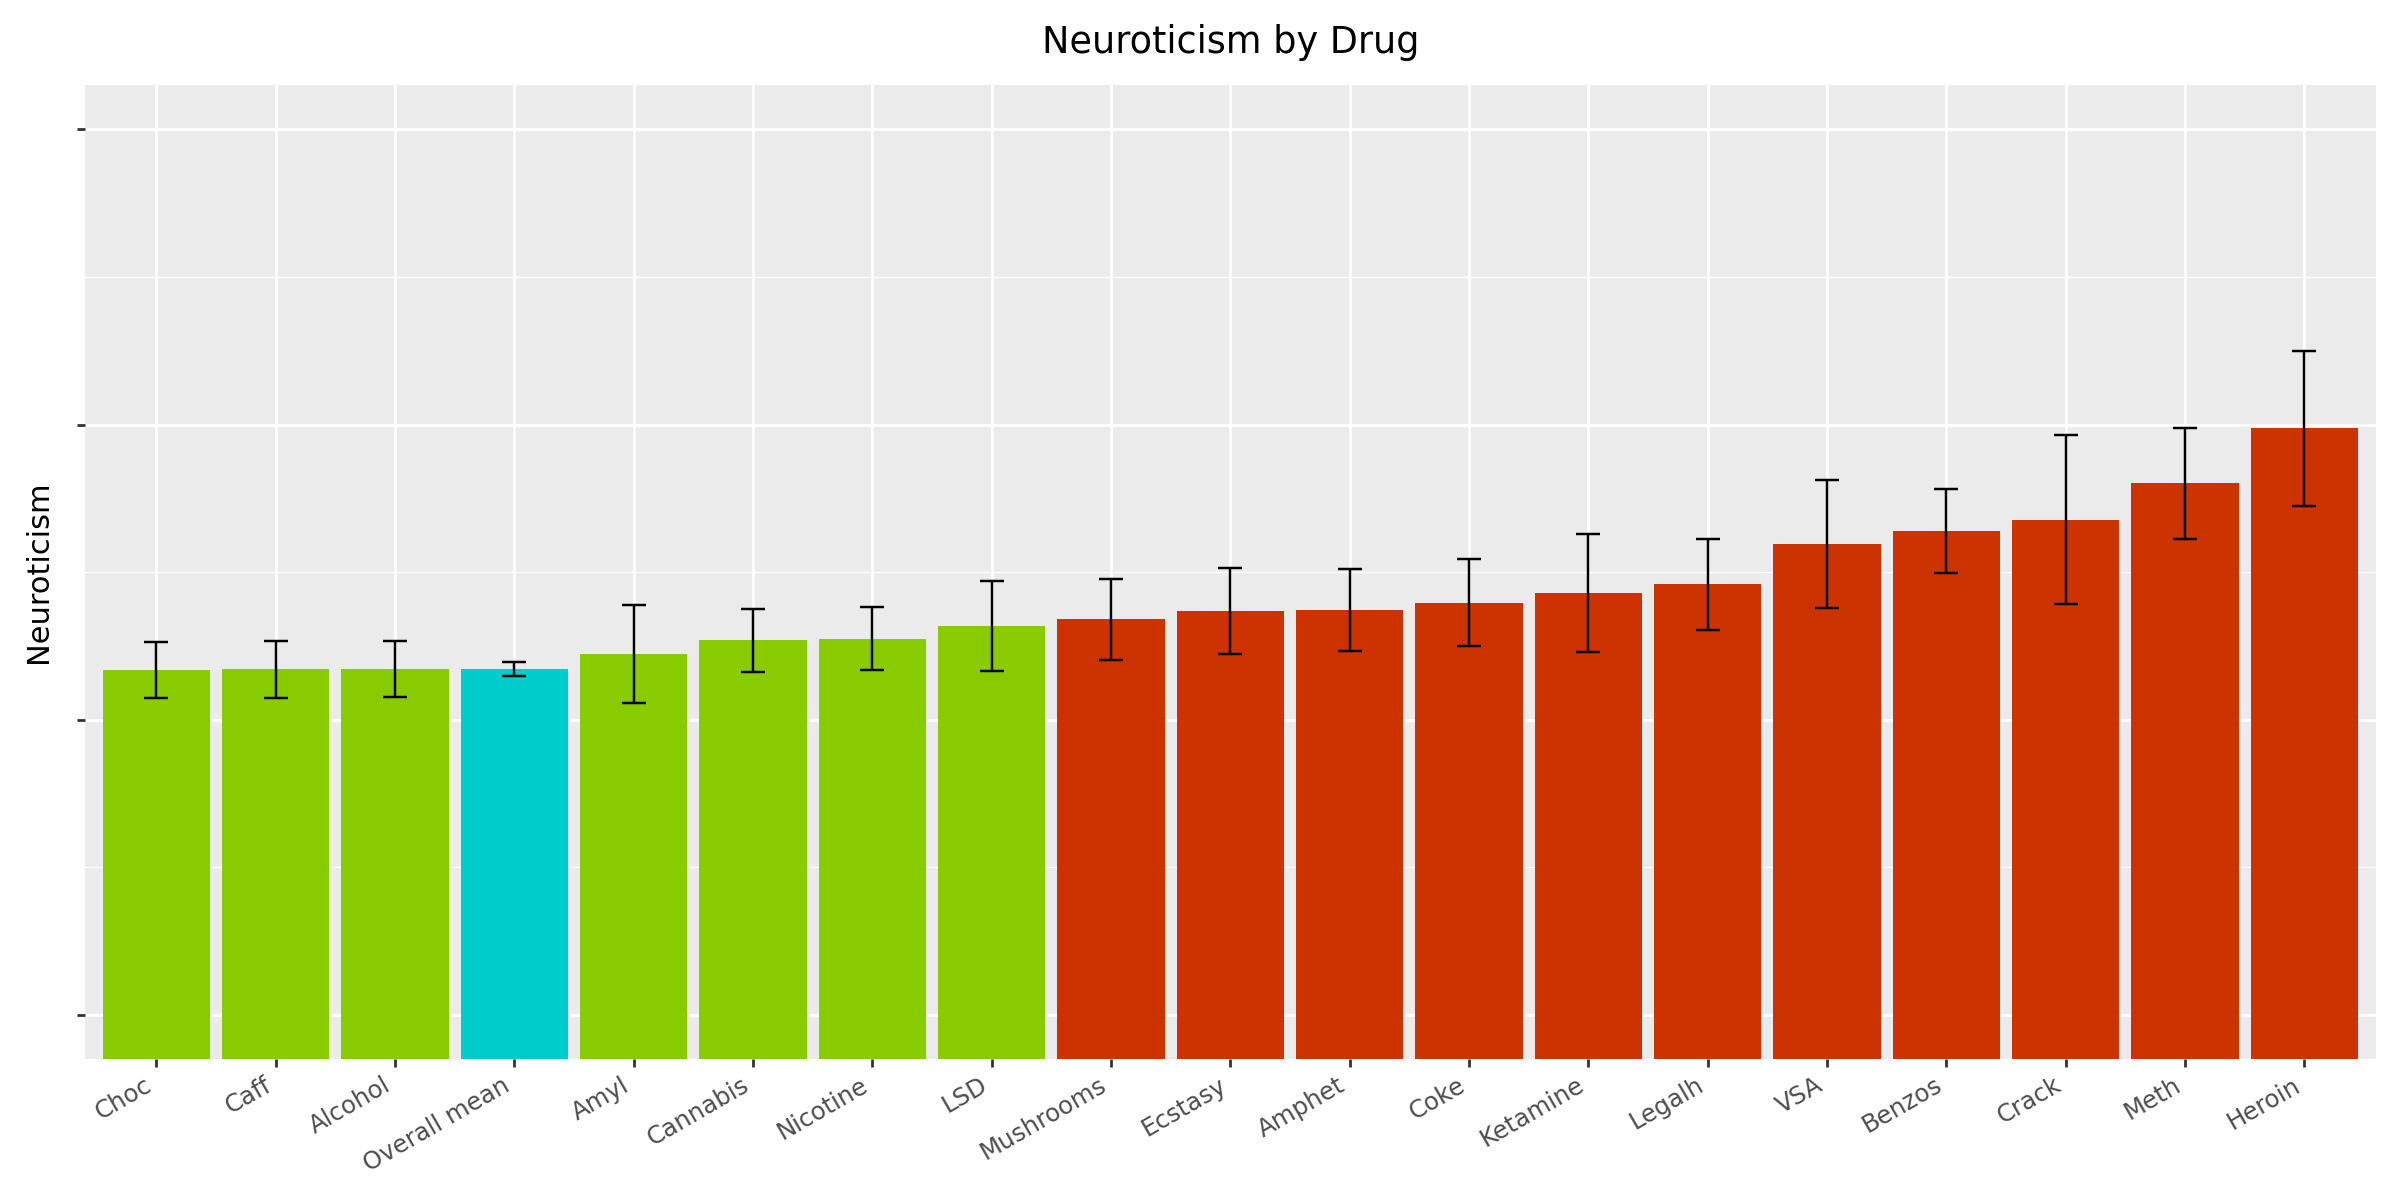

In [42]:
pn_config(nscores, "Neuroticism", (30, 45))

**Neuroticism** isn't as heavily impacted as some other traits, but it is nonetheless clearly visible, that drug-users become more neurotic, and thus less emotionally stable than non-users. 

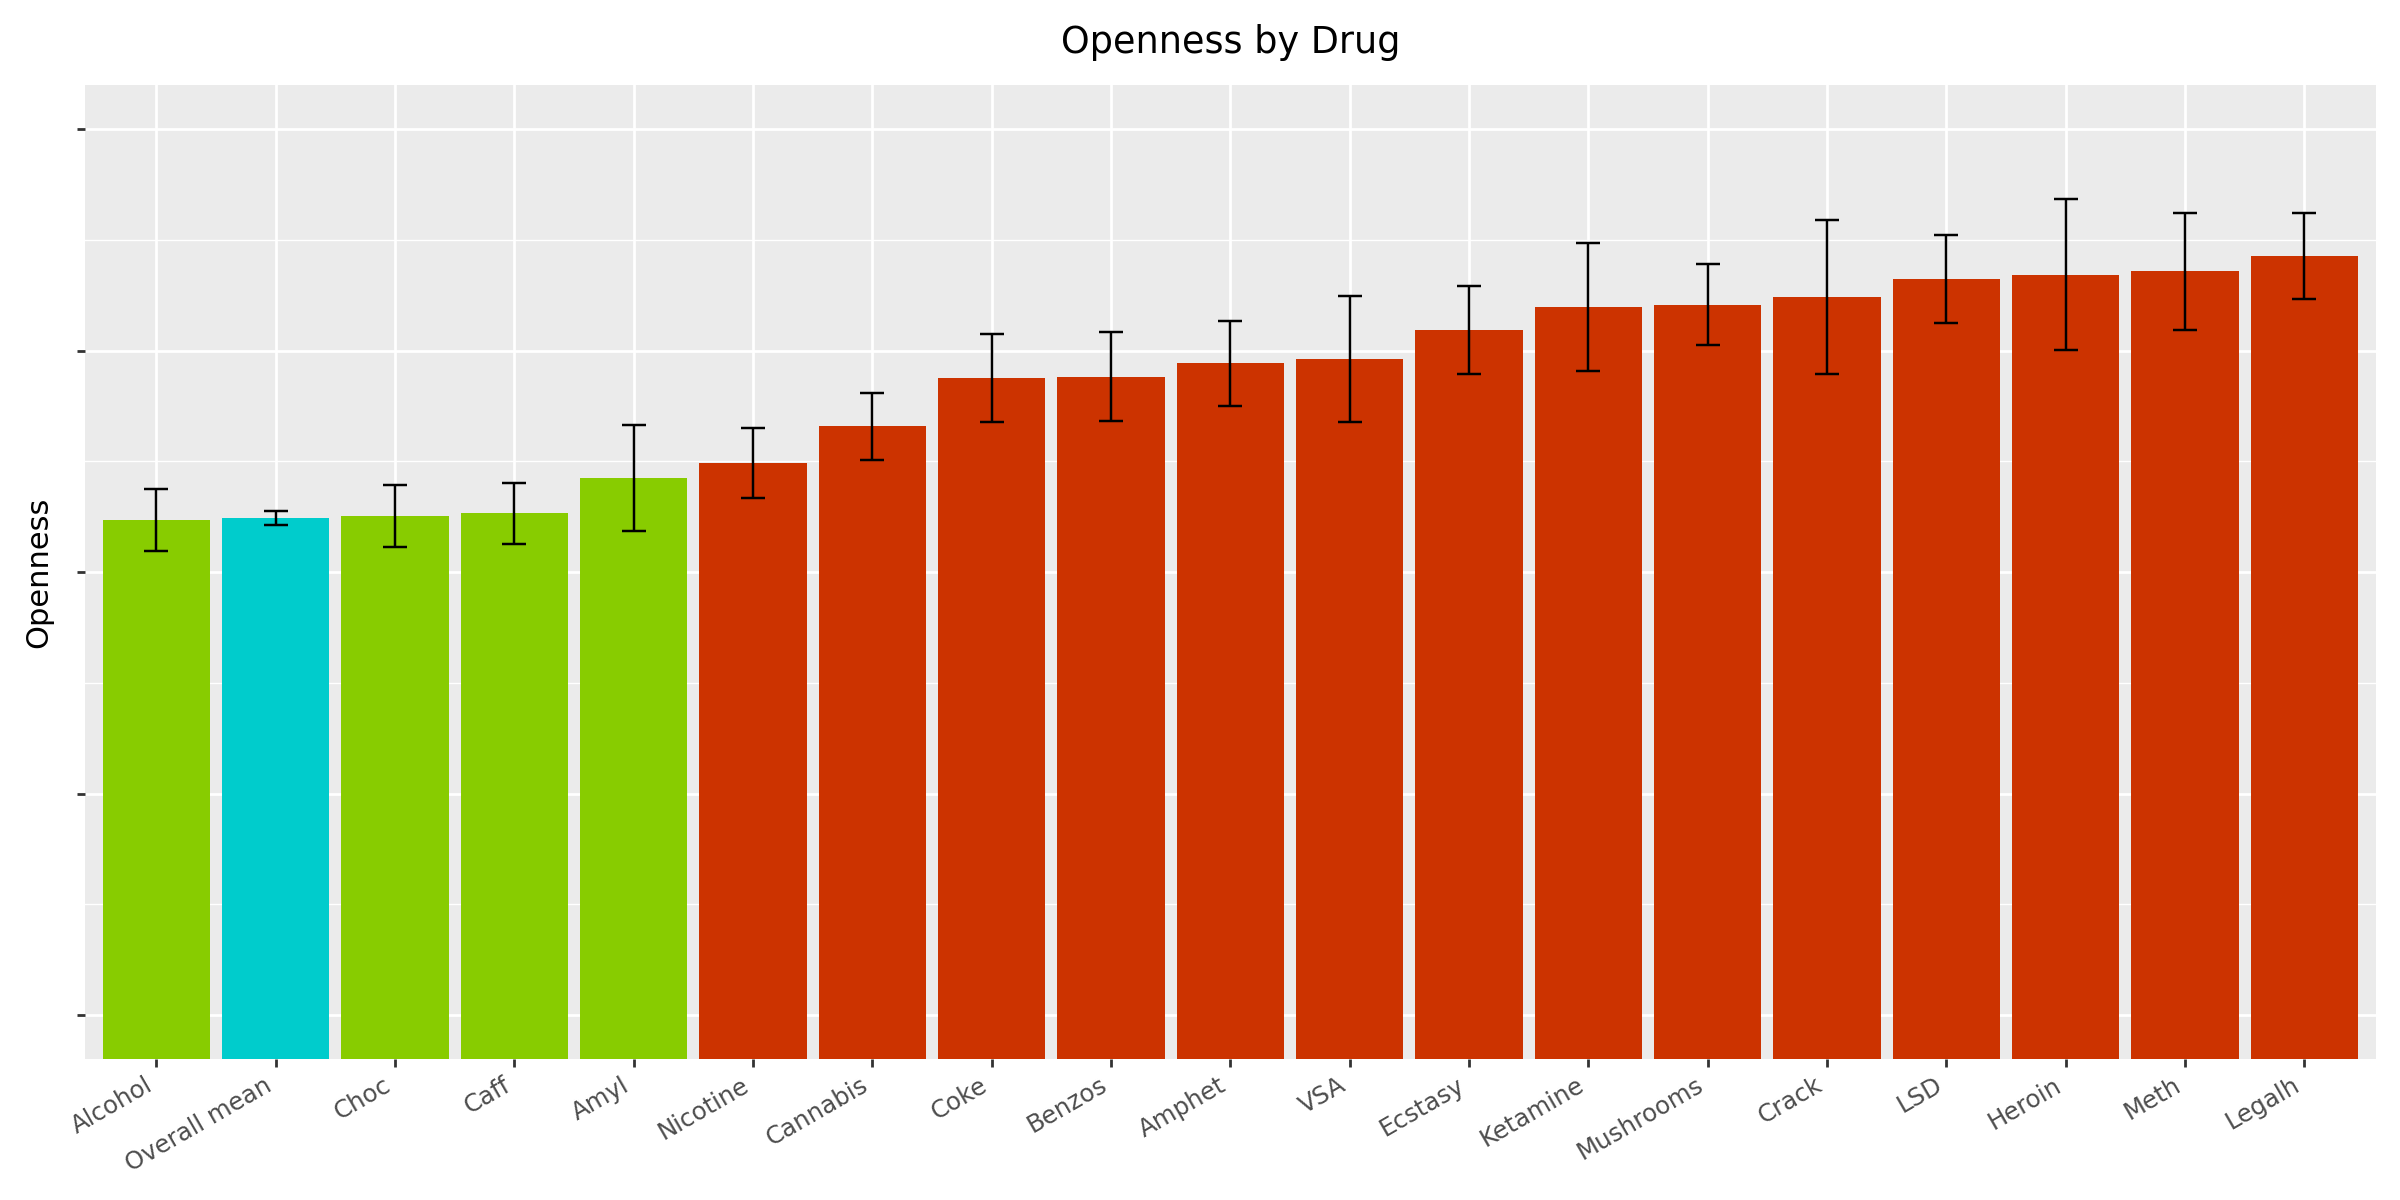

In [43]:
pn_config(oscores, "Openness", (40, 50))

Also, as expected, **drug-users have higher Openness scores** than regular users. They tend to see and imagine things due to doing drugs. They also tend to be more open and sociable.

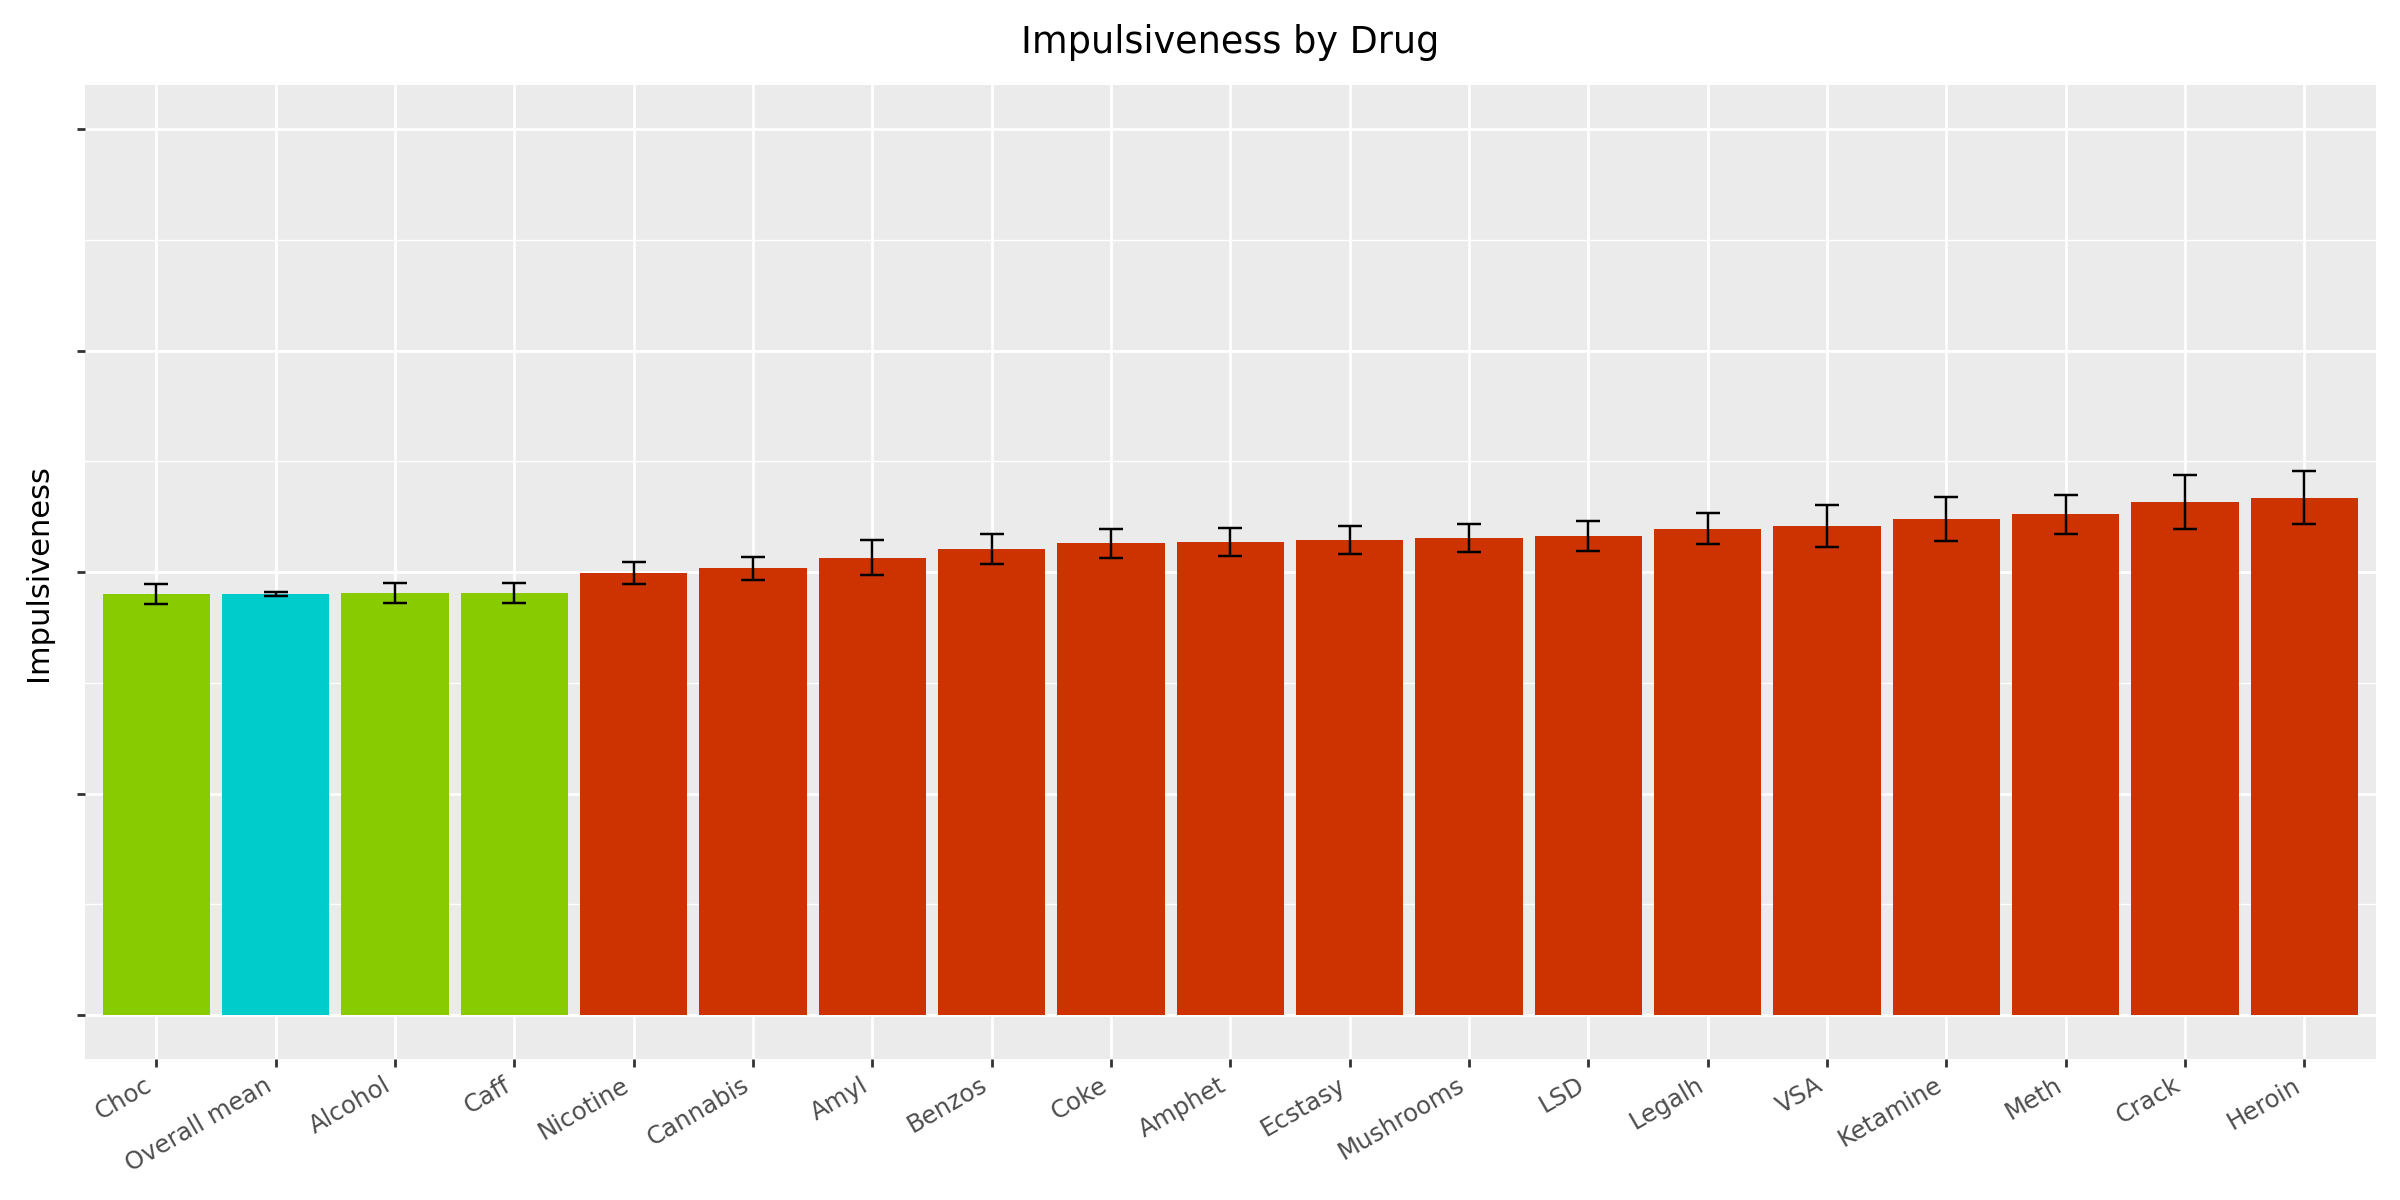

In [44]:
pn_config(impulsive, "Impulsiveness", (0, 10))

Another change we could expect was **drug-users becoming more impulsive**. They tend to do more rash decisions, and think less in the bigger picture.

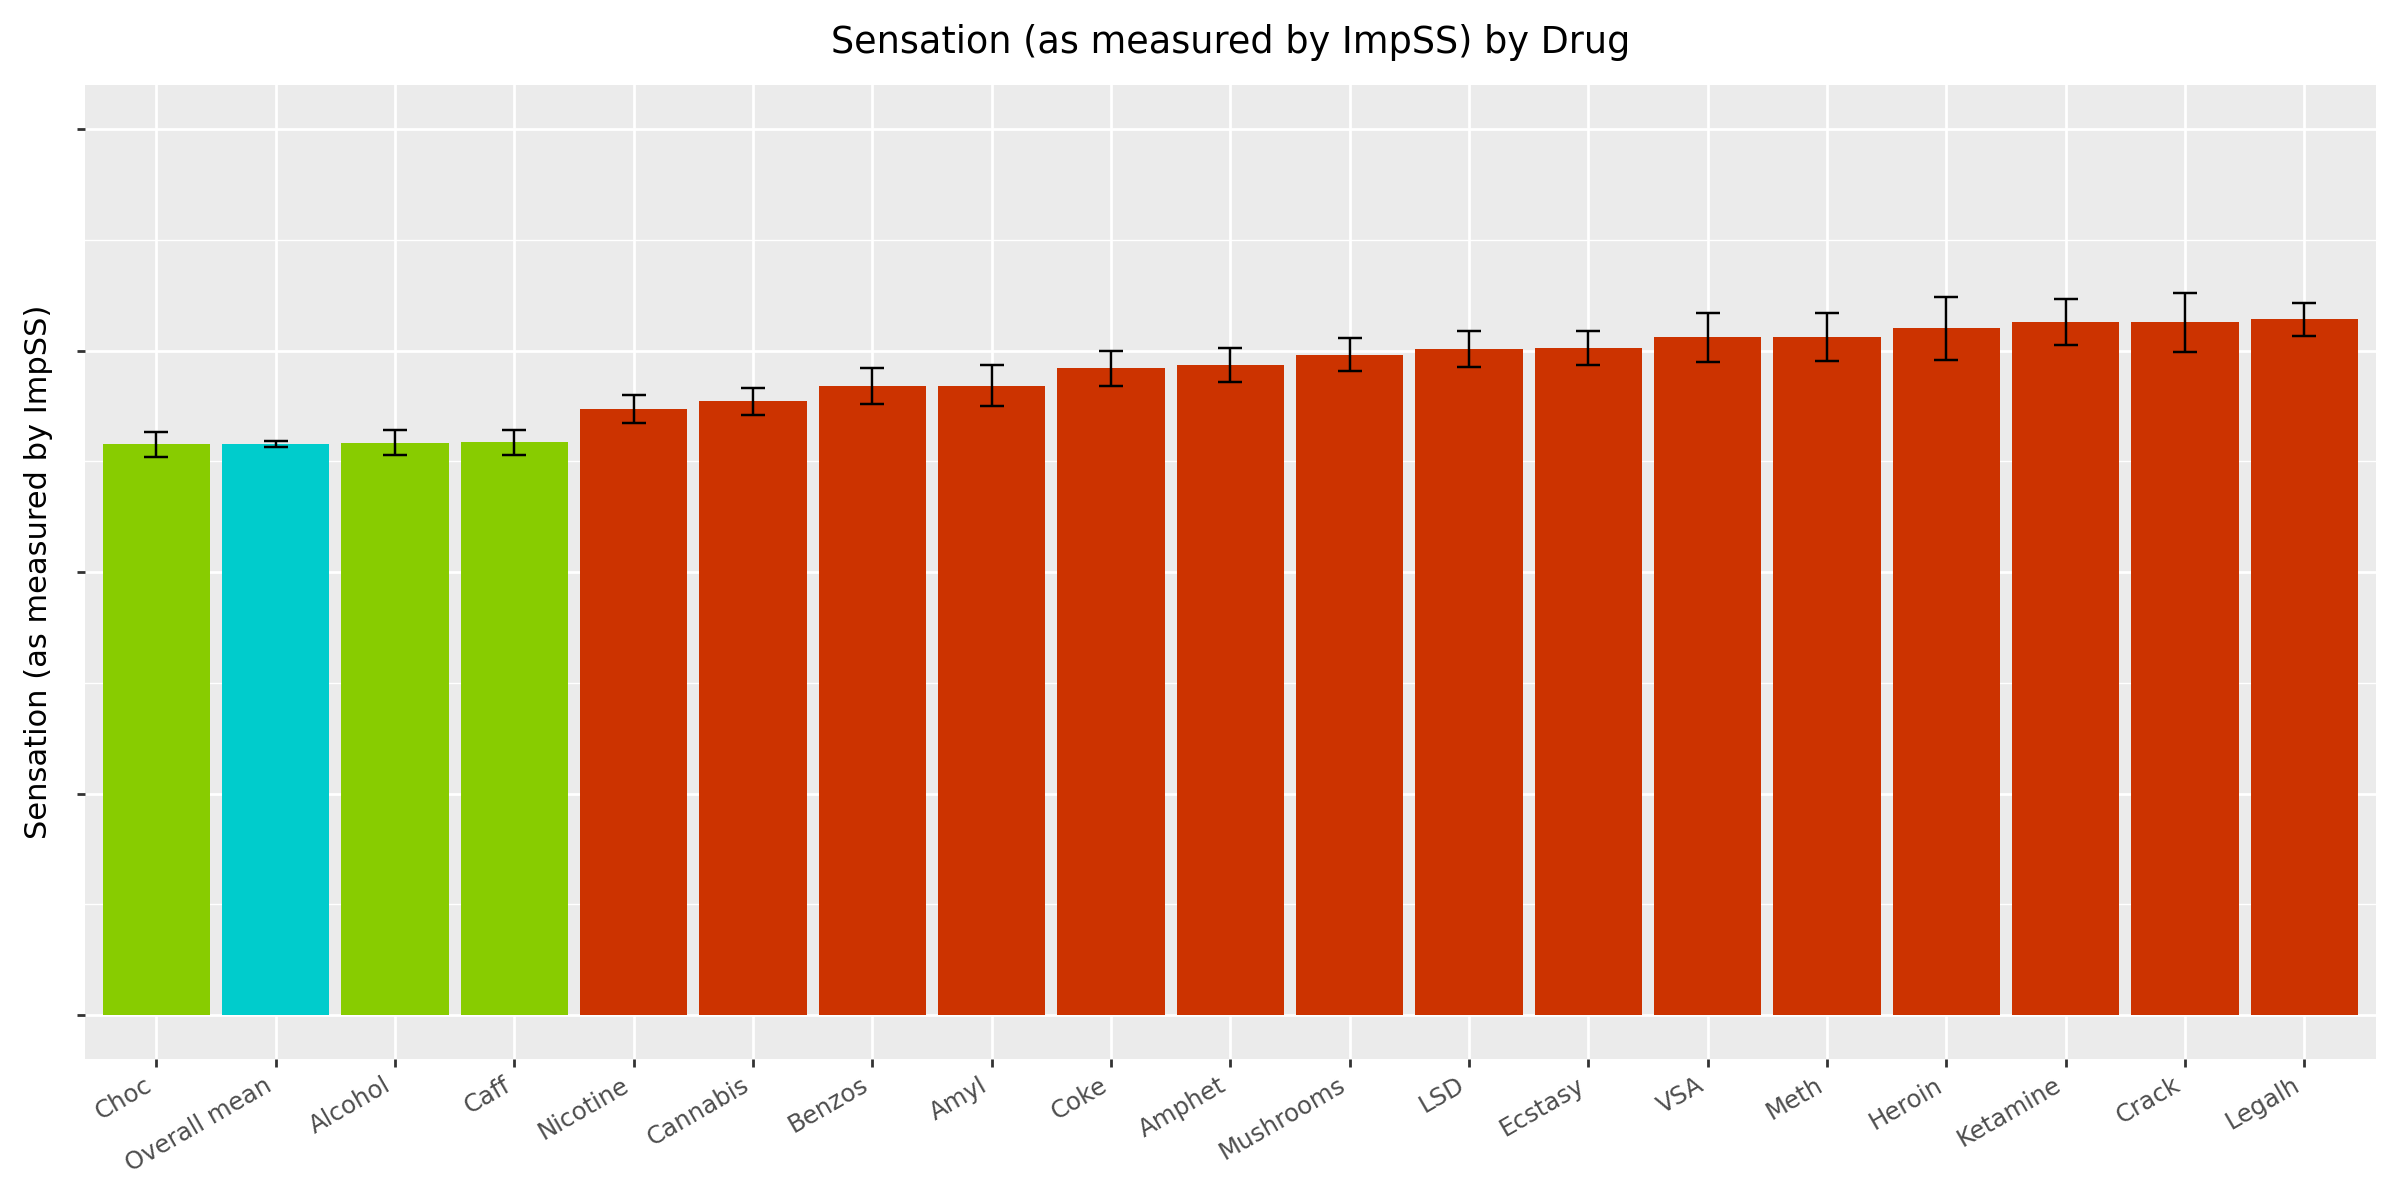

In [45]:
pn_config(ss, "Sensation (as measured by ImpSS)", (0, 10))

**Drug users also tend to become more sensory**, receiving more information through their senses than non-users. 

## Drugs and Their Co-Usage

For the last thing, lets see if we manage to cluster some drugs, which tend to be commonly used together. 

In [46]:
recent = ["Used in Last Day", "Used in Last Week", "Used in Last Month"]

In [47]:
df_recent = human_readable_data[data_reading.DRUG_TYPES].apply(
    lambda col: col.isin(recent)
)

In [48]:
pair_counts = []

for d1 in data_reading.DRUG_TYPES:
    for d2 in data_reading.DRUG_TYPES:
        if d1 >= d2:        # skip duplicates + skip same drug
            continue
        count = (df_recent[d1] & df_recent[d2]).sum()
        pair_counts.append((d1, d2, count))
pair_counts = pd.DataFrame(pair_counts, columns=["Drug1", "Drug2", "Count"])

In [49]:
from sklearn.cluster import KMeans


# ---- 2) Build symmetric co-usage matrix (features for KMeans) ----
drugs = sorted(set(pair_counts["Drug1"]) | set(pair_counts["Drug2"]))

matrix = pd.DataFrame(0, index=drugs, columns=drugs)

for _, row in pair_counts.iterrows():
    d1, d2, c = row["Drug1"], row["Drug2"], row["Count"]
    matrix.loc[d1, d2] = c
    matrix.loc[d2, d1] = c  # symmetric

# Each row = one drug, features = co-usage with other drugs
X = matrix.values

In [50]:
# ---- 3) KMeans clustering ----
# choose number of clusters (e.g. 2 or 3)
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X)

cluster_df = pd.DataFrame({
    "Drug": drugs,
    "Cluster": clusters
})
cluster_df.sort_values("Cluster", ascending=True)

,Drug,Cluster
6,Choc,0
1,Amphet,1
13,Legalh,1
9,Ecstasy,1
4,Caff,2
0,Alcohol,3
5,Cannabis,4
11,Ketamine,5
16,Nicotine,6
14,Meth,7


Opposite to what we expected, clustering shows, that **Alcohol, Nicotine, Chocolate, Cannabis and Caffeine**, 4 most used drugs in this dataset, aren't related to each other at all. It does cluster other drugs together into a few large groups, generally classifying as **Social Drugs** and **Hard Drugs**.

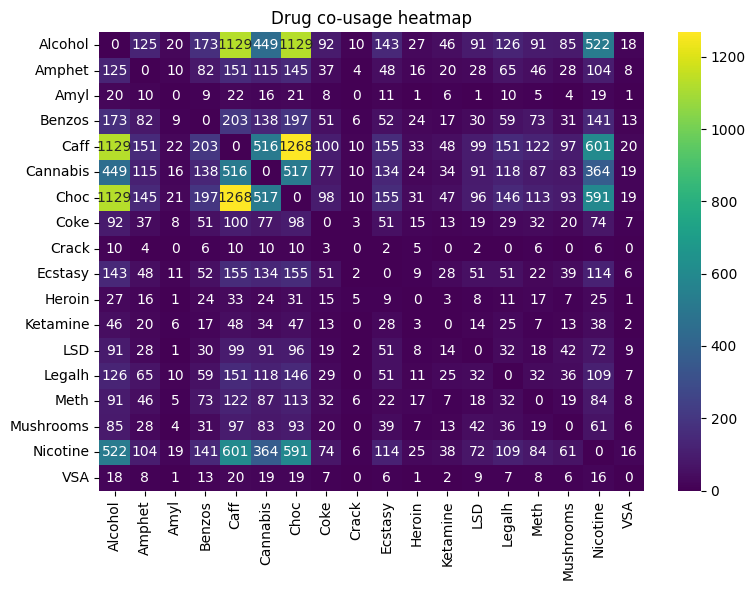

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    matrix,
    annot=True,      # show counts in cells
    fmt=".0f", # amount of comma places in numbers
    cmap="viridis",   #color
)
plt.title("Drug co-usage heatmap")
plt.tight_layout()
plt.show()

Heatmap show that most common drugs used together are **Caffeine, Chocolate, Cannabis, Alcohol and Nicotine**. They are most commonly used together with other drugs, but other than that it is hard to read out from the heatmap, if there are any other common drugs used together.

One of the drugs which is commonly used with other drugs is Amphetamines, which is commonly used together with **Legal highs, Methamphetamines and Ecstasy**.

**Ecstasy users** also commonly use other party drugs, like **LSD, Legal highs, Coke and Amphetamines**.